# Pairs Trading amb Dades Reals

Aplicarem la metodologia desenvolupada en simulació a dades reals.

L'objectiu no serà maximitzar el backtest, sinó comprovar si el comportament observat en simulació sobreviu fora del model generador.

Treballarem inicialment amb dades diàries i mantindrem una separació temporal estricta entre:

$$
\text{train}
\rightarrow
\text{validation}
\rightarrow
\text{test}.
$$

La selecció de parelles, els paràmetres i qualsevol decisió del model només podran utilitzar informació disponible en el passat.

In [1]:
%pip install numpy pandas matplotlib yfinance

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

## 1. Univers inicial

Començarem amb ETFs líquids que representen exposicions econòmiques similars.

Les parelles candidates es defineixen abans d'analitzar els seus resultats:

| Parella | Exposició aproximada |
|---|---|
| SPY — IVV | S&P 500 |
| XLF — VFH | sector financer |
| XLK — VGT | sector tecnològic |
| XLE — VDE | sector energètic |
| XLV — VHT | sector salut |

L'objectiu no és assumir que aquestes parelles són necessàriament bones per a mean reversion.

Posteriorment estudiarem si la seva relació estadística és prou estable utilitzant únicament el període de training.

In [3]:
parelles_candidates = {
    "SPY_IVV": ("SPY", "IVV"),
    "XLF_VFH": ("XLF", "VFH"),
    "XLK_VGT": ("XLK", "VGT"),
    "XLE_VDE": ("XLE", "VDE"),
    "XLV_VHT": ("XLV", "VHT")
}

tickers = sorted({
    ticker
    for parella in parelles_candidates.values()
    for ticker in parella
})

tickers

['IVV', 'SPY', 'VDE', 'VFH', 'VGT', 'VHT', 'XLE', 'XLF', 'XLK', 'XLV']

## 2. Obtenció de les dades

Utilitzarem dades diàries ajustades.

Fixarem una data final concreta perquè el conjunt de dades sigui reproduïble i no canviï automàticament cada vegada que executem el notebook.

Començarem l'any 2010, obtenint així un període suficientment llarg per separar posteriorment training, validation i test.

In [4]:
data_inici = "2010-01-01"
data_final = "2026-09-30"

dades_raw = yf.download(
    tickers=tickers,
    start=data_inici,
    end=data_final,
    auto_adjust=True,
    progress=False
)

preus = dades_raw["Close"].copy()

preus

Ticker,IVV,SPY,VDE,VFH,VGT,VHT,XLE,XLF,XLK,XLV
Date,,,,,,,,,,
2010-01-04,84.413345,84.368996,54.036270,21.138947,6.020539,43.541088,17.043320,8.879746,9.356692,23.788486
2010-01-05,84.658432,84.592316,54.589367,21.374846,6.014068,43.271626,17.182421,9.042952,9.344633,23.555199
2010-01-06,84.725273,84.651848,55.217918,21.410593,5.971988,43.517303,17.388184,9.061090,9.240085,23.796021
2010-01-07,85.096680,85.009178,55.085930,21.825216,5.949329,43.667873,17.362104,9.254523,9.203897,23.878798
2010-01-08,85.386353,85.292084,55.500767,21.739437,5.995725,43.826385,17.475124,9.200115,9.264213,23.916424
...,...,...,...,...,...,...,...,...,...,...
2026-09-22,776.809998,773.380005,173.287994,133.673996,126.263000,319.231018,61.779999,54.799999,196.270004,169.889999
2026-09-23,771.210022,767.809998,174.750000,132.869995,125.599998,316.179993,62.369999,54.540001,195.339996,168.800003
2026-09-24,770.619995,767.179993,175.419998,132.850006,125.190002,318.420013,62.599998,54.529999,194.710007,169.869995


In [5]:
print(
    f"Primera data: {preus.index.min().date()}"
)

print(
    f"Última data:  {preus.index.max().date()}"
)

print(
    f"Sessions:     {len(preus)}"
)

print(
    f"Actius:       {preus.shape[1]}"
)

Primera data: 2010-01-04
Última data:  2026-09-28
Sessions:     4209
Actius:       10


### 2.1. Qualitat de les dades

Abans de construir spreads o regressions comprovarem la disponibilitat de dades de cada actiu.

No omplirem automàticament els valors absents sense entendre primer per què existeixen.

In [6]:
resum_dades = pd.DataFrame({
    "Primera_Data": [
        preus[col].first_valid_index()
        for col in preus.columns
    ],
    
    "Ultima_Data": [
        preus[col].last_valid_index()
        for col in preus.columns
    ],
    
    "Observacions": [
        preus[col].notna().sum()
        for col in preus.columns
    ],
    
    "Valors_Nulls": [
        preus[col].isna().sum()
        for col in preus.columns
    ]
},
index=preus.columns)

resum_dades

,Primera_Data,Ultima_Data,Observacions,Valors_Nulls
Ticker,,,,
IVV,2010-01-04,2026-09-28,4209,0
SPY,2010-01-04,2026-09-28,4209,0
VDE,2010-01-04,2026-09-28,4209,0
VFH,2010-01-04,2026-09-28,4209,0
VGT,2010-01-04,2026-09-28,4209,0
VHT,2010-01-04,2026-09-28,4209,0
XLE,2010-01-04,2026-09-28,4209,0
XLF,2010-01-04,2026-09-28,4209,0
XLK,2010-01-04,2026-09-28,4209,0


### 2.2. Dataset congelat

Guardarem una còpia local dels preus utilitzats.

A partir d'aquest punt, els experiments del projecte podran reproduir-se utilitzant exactament el mateix conjunt de dades.

In [7]:
preus.to_csv(
    "preus_etf_daily_2010_2026.csv"
)

print(
    "Dataset guardat:",
    preus.shape
)

Dataset guardat: (4209, 10)


## 3. Separació temporal: train, validation i test

Abans d'analitzar les parelles dividirem les dades temporalment.

Utilitzarem:

- **Train:** 2010–2018
- **Validation:** 2019–2022
- **Test:** 2023–2026

$$
\text{Train}
\rightarrow
\text{Validation}
\rightarrow
\text{Test}
$$

El període de **train** es podrà utilitzar per estudiar les parelles i estimar paràmetres.

El període de **validation** servirà per comparar decisions o variants del model.

El període de **test** quedarà completament reservat fins al final.

No utilitzarem informació del test per seleccionar parelles, paràmetres o regles de trading.

In [8]:
# ==========================================
# SEPARACIÓ TEMPORAL
# ==========================================

train = preus.loc[
    "2010-01-01":"2018-12-31"
].copy()

validation = preus.loc[
    "2019-01-01":"2022-12-31"
].copy()

test = preus.loc[
    "2023-01-01":"2026-12-31"
].copy()


print("TRAIN")
print(
    train.index.min().date(),
    "→",
    train.index.max().date()
)
print("Observacions:", len(train))


print("\nVALIDATION")
print(
    validation.index.min().date(),
    "→",
    validation.index.max().date()
)
print("Observacions:", len(validation))


print("\nTEST")
print(
    test.index.min().date(),
    "→",
    test.index.max().date()
)
print("Observacions:", len(test))

TRAIN
2010-01-04 → 2018-12-31
Observacions: 2264

VALIDATION
2019-01-02 → 2022-12-30
Observacions: 1008

TEST
2023-01-03 → 2026-09-28
Observacions: 937


In [9]:
# ==========================================
# DISTRIBUCIÓ DE LES OBSERVACIONS
# ==========================================

resum_periodes = pd.DataFrame({
    "Inici": [
        train.index.min(),
        validation.index.min(),
        test.index.min()
    ],
    
    "Final": [
        train.index.max(),
        validation.index.max(),
        test.index.max()
    ],
    
    "Sessions": [
        len(train),
        len(validation),
        len(test)
    ]
},
index=[
    "Train",
    "Validation",
    "Test"
])

resum_periodes

,Inici,Final,Sessions
Train,2010-01-04,2018-12-31,2264
Validation,2019-01-02,2022-12-30,1008
Test,2023-01-03,2026-09-28,937


### 3.1. Log-preus

Treballarem principalment amb log-preus:

$$
P_t^{log}=\log(P_t).
$$

Això permet expressar la relació entre dos actius mitjançant:

$$
\log(A_t)
=
\alpha
+
\beta\log(B_t)
+
S_t,
$$

on $S_t$ representa el spread o desviació respecte de la relació estimada.

In [10]:
# ==========================================
# LOG-PREUS
# ==========================================

log_train = np.log(train)

log_validation = np.log(validation)

log_test = np.log(test)

## 4. Primera anàlisi de les parelles

Començarem comparant dues mesures diferents:

1. correlació dels **retorns diaris**;
2. correlació dels **log-preus**.

La correlació dels retorns ens indica fins a quin punt dos actius tendeixen a moure's conjuntament dia a dia.

En canvi, una correlació elevada entre nivells de preus no garanteix que existeixi una relació estable de mean reversion.

Dos actius poden presentar una tendència comuna i tenir una correlació molt elevada sense que el seu spread sigui estacionari.

Per tant:

$$
\text{correlació alta}
\neq
\text{cointegració}
\neq
\text{mean reversion}.
$$

En aquesta secció utilitzarem exclusivament el període de training.

In [11]:
# RETORNS DIARIS

retorns_train = train.pct_change().dropna()

retorns_train.head(6)

Ticker,IVV,SPY,VDE,VFH,VGT,VHT,XLE,XLF,XLK,XLV
Date,,,,,,,,,,
2010-01-05,0.002903,0.002647,0.010236,0.011159,-0.001075,-0.006189,0.008162,0.018379,-0.001289,-0.009807
2010-01-06,0.000790,0.000704,0.011514,0.001672,-0.006997,0.005678,0.011975,0.002006,-0.011188,0.010224
2010-01-07,0.004384,0.004221,-0.002390,0.019365,-0.003794,0.003460,-0.001500,0.021348,-0.003916,0.003479
2010-01-08,0.003404,0.003328,0.007531,-0.003930,0.007799,0.003630,0.006510,-0.005879,0.006553,0.001576
2010-01-11,0.001391,0.001397,-0.000793,-0.000329,-0.004319,0.005063,-0.001327,0.000657,-0.003906,0.005664
2010-01-12,-0.009207,-0.009326,-0.015755,-0.012171,-0.013194,-0.006837,-0.014447,-0.014445,-0.010893,-0.007196


In [12]:
# CORRELACIONS DE LES PARELLES

resultats_correlacio = []

for nom_parella, (ticker_A, ticker_B) in parelles_candidates.items():

    correlacio_retorns = (
        retorns_train[ticker_A]
        .corr(retorns_train[ticker_B])
    )

    correlacio_log_preus = (
        log_train[ticker_A]
        .corr(log_train[ticker_B])
    )

    resultats_correlacio.append({
        "Parella": nom_parella,
        "Actiu_A": ticker_A,
        "Actiu_B": ticker_B,
        "Corr_Retorns": correlacio_retorns,
        "Corr_Log_Preus": correlacio_log_preus
    })


correlacions_parelles = pd.DataFrame(
    resultats_correlacio
)

correlacions_parelles

,Parella,Actiu_A,Actiu_B,Corr_Retorns,Corr_Log_Preus
0,SPY_IVV,SPY,IVV,0.998512,0.999990
1,XLF_VFH,XLF,VFH,0.993279,0.999355
2,XLK_VGT,XLK,VGT,0.989136,0.999129
3,XLE_VDE,XLE,VDE,0.995695,0.976764
4,XLV_VHT,XLV,VHT,0.988572,0.999769


### 4.1. Estabilitat temporal de la correlació

Una única correlació calculada sobre nou anys pot ocultar canvis importants.

Per això estudiarem també la correlació rolling dels retorns:

$$
\rho_t
=
Corr(
R^A_{t-59:t},
R^B_{t-59:t}
).
$$

Utilitzarem una finestra de 60 sessions, aproximadament tres mesos de mercat.

Una bona parella no necessita tenir correlació perfecta, però ens interessa saber si la seva relació és persistent o canvia radicalment amb el temps.

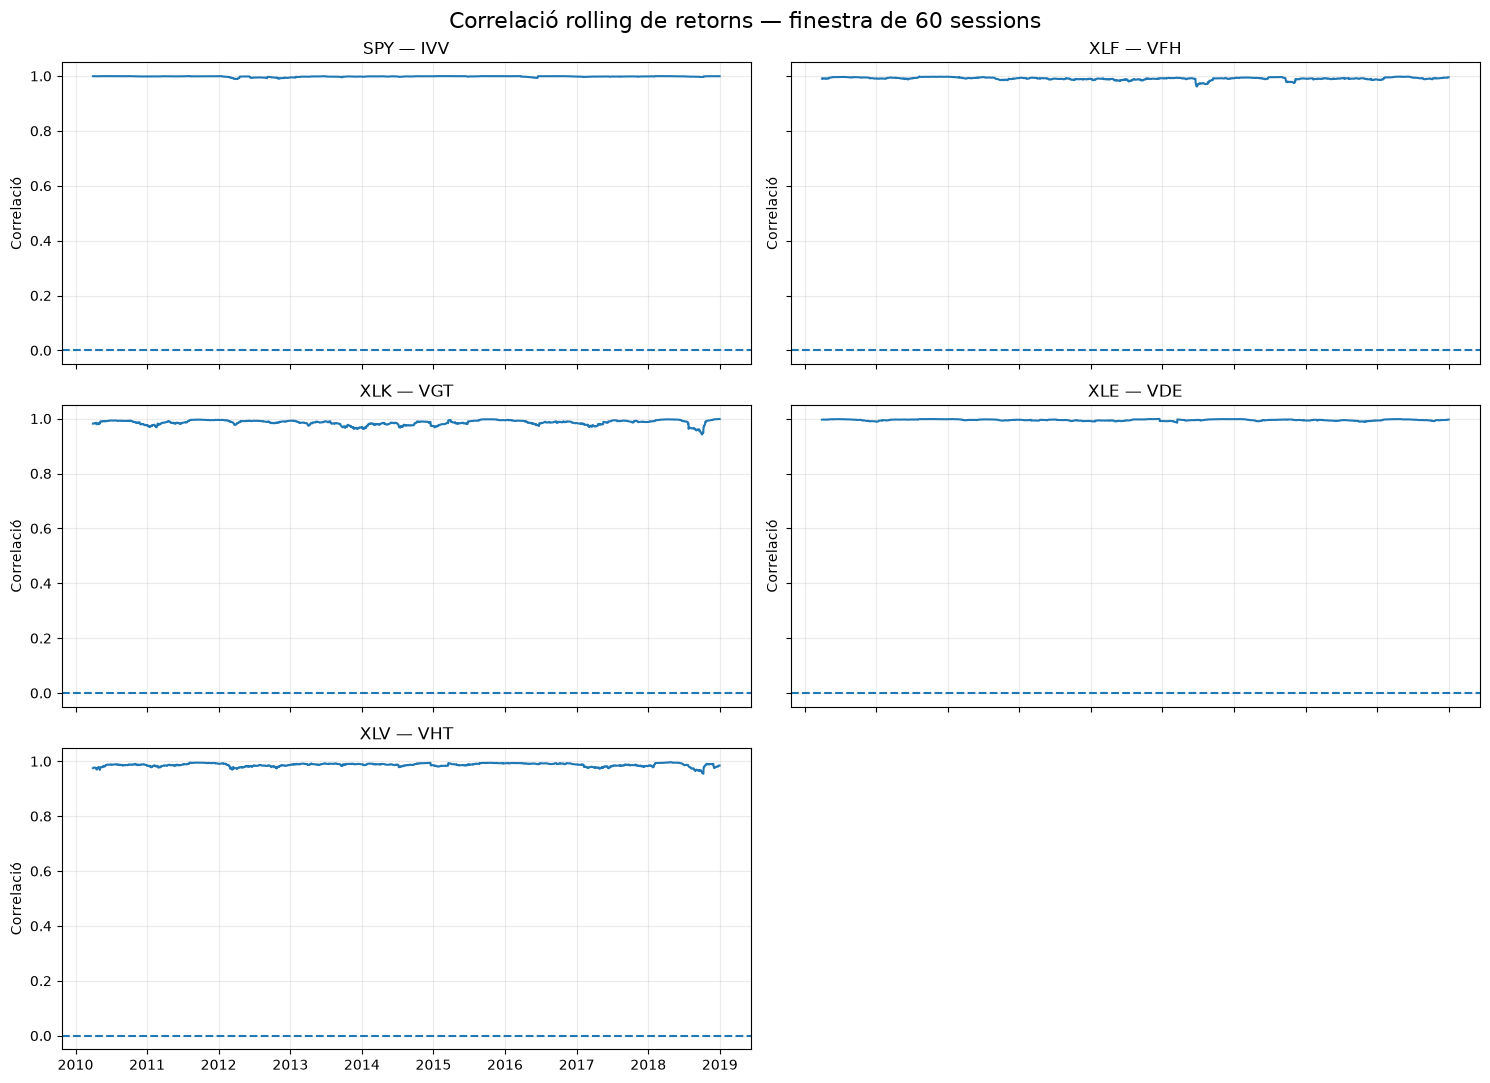

In [13]:
# CORRELACIÓ ROLLING DE 60 SESSIONS

fig, axes = plt.subplots(
    3,
    2,
    figsize=(15, 11),
    sharex=True,
    sharey=True
)

axes = axes.flatten()


for ax, (
    nom_parella,
    (ticker_A, ticker_B)
) in zip(
    axes,
    parelles_candidates.items()
):

    corr_rolling = (
        retorns_train[ticker_A]
        .rolling(60)
        .corr(retorns_train[ticker_B])
    )

    ax.plot(
        corr_rolling.index,
        corr_rolling
    )

    ax.axhline(
        0,
        linestyle="--"
    )

    ax.set_title(
        f"{ticker_A} — {ticker_B}"
    )

    ax.set_ylabel(
        "Correlació"
    )

    ax.grid(
        alpha=0.25
    )


axes[-1].axis("off")

fig.suptitle(
    "Correlació rolling de retorns — finestra de 60 sessions",
    fontsize=16
)

plt.tight_layout()

plt.show()

### 4.2. Matriu de correlacions

Fins ara només hem estudiat les cinc parelles definides inicialment.

Amb 10 actius existeixen:

$$
\binom{10}{2}=45
$$

parelles diferents.

Calcularem la matriu completa de correlacions dels retorns diaris utilitzant exclusivament el període de training.

Aquesta anàlisi serveix per detectar altres actius que presenten moviments similars, però una correlació elevada encara no implica que siguin una bona parella de mean reversion.

In [14]:
# MATRIU DE CORRELACIONS DELS RETORNS

matriu_correlacions = (
    retorns_train
    .corr()
)

matriu_correlacions.round(3)

Ticker,IVV,SPY,VDE,VFH,VGT,VHT,XLE,XLF,XLK,XLV
Ticker,,,,,,,,,,
IVV,1.000,0.999,0.793,0.904,0.917,0.871,0.802,0.900,0.919,0.861
SPY,0.999,1.000,0.793,0.905,0.918,0.871,0.802,0.900,0.920,0.861
VDE,0.793,0.793,1.000,0.709,0.669,0.624,0.996,0.703,0.659,0.609
VFH,0.904,0.905,0.709,1.000,0.771,0.751,0.715,0.993,0.764,0.735
VGT,0.917,0.918,0.669,0.771,1.000,0.779,0.675,0.764,0.989,0.753
VHT,0.871,0.871,0.624,0.751,0.779,1.000,0.632,0.744,0.776,0.989
XLE,0.802,0.802,0.996,0.715,0.675,0.632,1.000,0.710,0.666,0.620
XLF,0.900,0.900,0.703,0.993,0.764,0.744,0.710,1.000,0.759,0.732
XLK,0.919,0.920,0.659,0.764,0.989,0.776,0.666,0.759,1.000,0.759


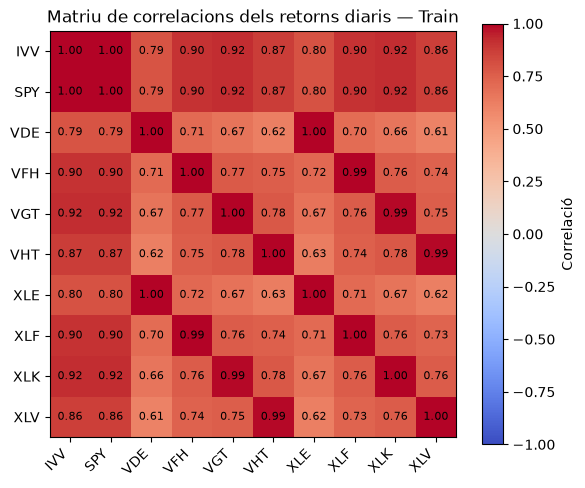

In [15]:
# HEATMAP DE CORRELACIONS

fig, ax = plt.subplots(
    figsize=(6, 5)
)

imatge = ax.imshow(
    matriu_correlacions,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

ax.set_xticks(
    range(len(matriu_correlacions.columns))
)

ax.set_yticks(
    range(len(matriu_correlacions.index))
)

ax.set_xticklabels(
    matriu_correlacions.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    matriu_correlacions.index
)


for i in range(len(matriu_correlacions.index)):

    for j in range(len(matriu_correlacions.columns)):

        ax.text(
            j,
            i,
            f"{matriu_correlacions.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )


fig.colorbar(
    imatge,
    ax=ax,
    label="Correlació"
)

ax.set_title(
    "Matriu de correlacions dels retorns diaris — Train"
)

plt.tight_layout()

plt.show()

In [16]:
# RÀNQUING DE TOTES LES PARELLES

parelles_correlacio = []

columnes = retorns_train.columns


for i in range(len(columnes)):

    for j in range(i + 1, len(columnes)):

        ticker_A = columnes[i]
        ticker_B = columnes[j]

        correlacio = (
            retorns_train[ticker_A]
            .corr(retorns_train[ticker_B])
        )

        parelles_correlacio.append({
            "Actiu_A": ticker_A,
            "Actiu_B": ticker_B,
            "Correlacio": correlacio
        })


ranking_correlacions = (
    pd.DataFrame(parelles_correlacio)
    .sort_values(
        "Correlacio",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_correlacions.head(10)

,Actiu_A,Actiu_B,Correlacio
0,IVV,SPY,0.998512
1,VDE,XLE,0.995695
2,VFH,XLF,0.993279
3,VGT,XLK,0.989136
4,VHT,XLV,0.988572
5,SPY,XLK,0.919579
6,IVV,XLK,0.919087
7,SPY,VGT,0.918000
8,IVV,VGT,0.917422
9,SPY,VFH,0.904877


## 5. De correlació a cointegració

Una correlació elevada dels retorns indica que dos actius tendeixen a moure's en la mateixa direcció.

Però per fer mean reversion necessitem una propietat més forta.

Buscarem una relació del tipus:

$$
\log(A_t)
=
\alpha
+
\beta \log(B_t)
+
S_t,
$$

on el spread

$$
S_t
=
\log(A_t)
-
\alpha
-
\beta\log(B_t)
$$

sigui estacionari.

Si el spread és estacionari, les desviacions respecte de la relació de llarg termini tendeixen a desaparèixer.

Aquesta propietat s'anomena **cointegració**.

Per estudiar-la utilitzarem exclusivament el període de training.

In [17]:
# INSTAL·LACIÓ DE STATSMODELS

%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [18]:
# IMPORTS ESTADÍSTICS

import statsmodels.api as sm

from statsmodels.tsa.stattools import (
    adfuller,
    coint
)

In [19]:
# REGRESSIÓ I TESTS DE COINTEGRACIÓ

resultats_cointegracio = []

spreads_train = {}


for nom_parella, (
    ticker_A,
    ticker_B
) in parelles_candidates.items():

    y = log_train[ticker_A]

    x = sm.add_constant(
        log_train[ticker_B]
    )

    model_ols = sm.OLS(
        y,
        x
    ).fit()


    alpha = (
        model_ols.params["const"]
    )

    beta = (
        model_ols.params[ticker_B]
    )


    spread = (
        y
        - alpha
        - beta * log_train[ticker_B]
    )


    spreads_train[
        nom_parella
    ] = spread


    # ADF sobre el spread
    resultat_adf = adfuller(
        spread.dropna()
    )

    adf_stat = resultat_adf[0]
    adf_pvalue = resultat_adf[1]


    # Test Engle-Granger directe
    coint_stat, coint_pvalue, _ = coint(
        y,
        log_train[ticker_B]
    )


    resultats_cointegracio.append({

        "Parella":
            nom_parella,

        "Alpha":
            alpha,

        "Beta":
            beta,

        "R2":
            model_ols.rsquared,

        "ADF_Stat":
            adf_stat,

        "ADF_pvalue":
            adf_pvalue,

        "Coint_Stat":
            coint_stat,

        "Coint_pvalue":
            coint_pvalue,

        "Std_Spread":
            spread.std()
    })


cointegracio_parelles = (
    pd.DataFrame(
        resultats_cointegracio
    )
    .sort_values(
        "Coint_pvalue"
    )
    .reset_index(
        drop=True
    )
)

cointegracio_parelles

C:\Users\Jordi\AppData\Local\Temp\ipykernel_15324\3650873240.py:47: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultat_adf = adfuller(
C:\Users\Jordi\AppData\Local\Temp\ipykernel_15324\3650873240.py:47: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultat_adf = adfuller(
C:\Users\Jordi\AppData\Local\Temp\ipykernel_15324\3650873240.py:47: FutureWarning: adfuller curr

,Parella,Alpha,Beta,R2,ADF_Stat,ADF_pvalue,Coint_Stat,Coint_pvalue,Std_Spread
0,XLF_VFH,-0.910993,1.002622,0.998710,-3.638876,0.005060,-3.636851,0.022043,0.012396
1,XLV_VHT,-0.555367,0.982600,0.999538,-3.512341,0.007676,-3.511766,0.031366,0.008916
2,SPY_IVV,-0.007962,1.001387,0.999980,-2.168140,0.218011,-2.168592,0.440614,0.001526
3,XLK_VGT,0.485797,0.979601,0.998259,-2.070900,0.256376,-2.073208,0.490377,0.016501
4,XLE_VDE,-1.215597,1.025301,0.954067,0.074206,0.964255,0.067415,0.987349,0.033244


### 5.1. Spreads estimats durant el training

Representarem els residus de les regressions de cointegració.

Si una parella presenta mean reversion, esperem observar un spread que oscil·la al voltant d'un nivell relativament estable en lloc de presentar una tendència persistent.

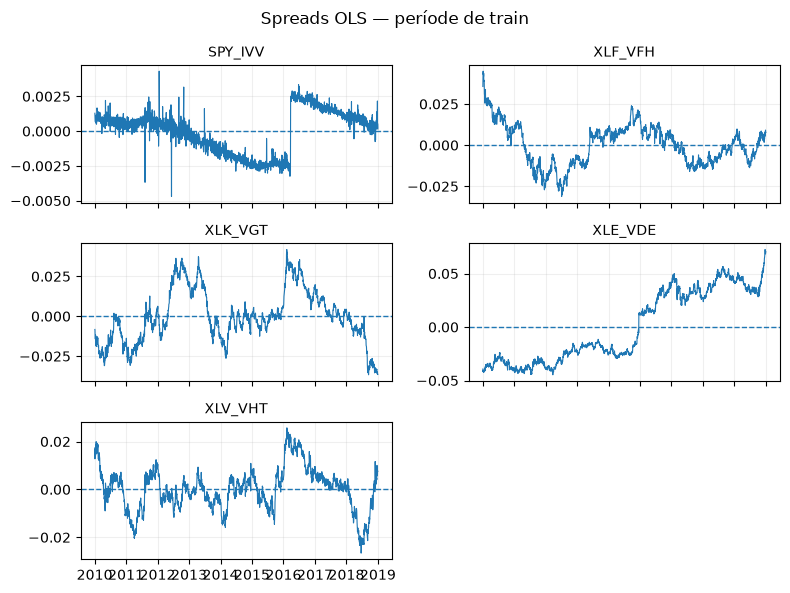

In [20]:
# SPREADS DE LES CINC PARELLES

fig, axes = plt.subplots(
    3,
    2,
    figsize=(8, 6),
    sharex=True
)

axes = axes.flatten()


for ax, (
    nom_parella,
    spread
) in zip(
    axes,
    spreads_train.items()
):

    ax.plot(
        spread.index,
        spread,
        linewidth=0.8
    )

    ax.axhline(
        spread.mean(),
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        nom_parella,
        fontsize=10
    )

    ax.grid(
        alpha=0.20
    )


axes[-1].axis("off")

fig.suptitle(
    "Spreads OLS — període de train",
    fontsize=12
)

plt.tight_layout()

plt.show()

### 5.2. Interpretació dels resultats

Les cinc parelles presenten correlacions molt elevades, però només dues mostren evidència de cointegració al nivell del 5%:

- XLF — VFH;
- XLV — VHT.

SPY — IVV és especialment instructiva: presenta una correlació i un $R^2$ gairebé perfectes, però el seu spread no és estacionari durant el període de training.

XLE — VDE també presenta una correlació molt elevada, però el spread mostra una tendència clara i el test de cointegració no troba cap evidència de mean reversion.

Per tant:

$$
\boxed{
\text{correlació elevada}
\neq
\text{cointegració}
}
$$

La correlació permet trobar parelles candidates, mentre que la cointegració estudia si existeix una combinació dels preus que tendeix a tornar a un equilibri.

Les candidates provisionals són XLF — VFH i XLV — VHT. Encara cal comprovar si la seva relació és estable en diferents subperíodes.

## 6. Estabilitat temporal de les relacions

Els tests anteriors assumeixen que una única relació és vàlida durant tot el període 2010–2018.

Però una parella pot presentar una relació econòmica persistent mentre els seus paràmetres evolucionen amb el temps:

$$
\log(A_t)
=
\alpha_t
+
\beta_t\log(B_t)
+
S_t.
$$

Per estudiar aquesta possibilitat mantindrem les cinc parelles i analitzarem:

1. cointegració en diferents subperíodes;
2. evolució rolling del hedge ratio $\beta$.

Això permetrà distingir entre:

$$
\text{relació inexistent}
$$

i

$$
\text{relació existent però dinàmica}.
$$

In [21]:
# COINTEGRACIÓ PER SUBPERÍODES

subperiodes_train = {
    "2010-2012": ("2010-01-01", "2012-12-31"),
    "2013-2015": ("2013-01-01", "2015-12-31"),
    "2016-2018": ("2016-01-01", "2018-12-31")
}

resultats_subperiodes = []


for nom_parella, (
    ticker_A,
    ticker_B
) in parelles_candidates.items():

    for nom_periode, (
        inici,
        final
    ) in subperiodes_train.items():

        y = log_train.loc[
            inici:final,
            ticker_A
        ]

        x = log_train.loc[
            inici:final,
            ticker_B
        ]

        X = sm.add_constant(x)

        model_ols = sm.OLS(
            y,
            X
        ).fit()

        alpha = model_ols.params["const"]
        beta = model_ols.params[ticker_B]

        spread = (
            y
            - alpha
            - beta * x
        )

        coint_stat, coint_pvalue, _ = coint(
            y,
            x
        )

        correlacio_retorns = (
            retorns_train.loc[
                inici:final,
                ticker_A
            ]
            .corr(
                retorns_train.loc[
                    inici:final,
                    ticker_B
                ]
            )
        )

        resultats_subperiodes.append({
            "Parella": nom_parella,
            "Periode": nom_periode,
            "Corr_Retorns": correlacio_retorns,
            "Alpha": alpha,
            "Beta": beta,
            "R2": model_ols.rsquared,
            "Coint_pvalue": coint_pvalue,
            "Std_Spread": spread.std()
        })


estabilitat_subperiodes = pd.DataFrame(
    resultats_subperiodes
)

estabilitat_subperiodes

,Parella,Periode,Corr_Retorns,Alpha,Beta,R2,Coint_pvalue,Std_Spread
0,SPY_IVV,2010-2012,0.998256,0.003504,0.998996,0.999978,2.922087e-08,0.000497
1,SPY_IVV,2013-2015,0.998840,0.018412,0.995801,0.999995,2.728213e-29,0.000282
2,SPY_IVV,2016-2018,0.998719,-0.004117,1.000887,0.999917,4.239465e-02,0.001235
3,XLF_VFH,2010-2012,0.994900,-0.929021,1.007927,0.957193,2.393827e-01,0.017314
4,XLF_VFH,2013-2015,0.989040,-1.075349,1.050630,0.997804,1.632226e-01,0.005512
5,XLF_VFH,2016-2018,0.992887,-0.953537,1.012347,0.998830,4.844568e-01,0.006090
6,XLK_VGT,2010-2012,0.990911,0.327309,1.060386,0.983935,4.599356e-01,0.015389
7,XLK_VGT,2013-2015,0.985316,0.578113,0.940281,0.995295,5.767355e-01,0.009874
8,XLK_VGT,2016-2018,0.990689,0.695948,0.906024,0.998542,7.971478e-01,0.007748
9,XLE_VDE,2010-2012,0.997002,-1.218083,1.017672,0.997850,6.512932e-01,0.006102


### 6.1. Hedge ratio rolling

Estimarem una regressió local utilitzant una finestra de 252 sessions.

Per una regressió amb intercept:

$$
\beta_t
=
\frac{
Cov_t(\log A,\log B)
}{
Var_t(\log B)
}
$$

i:

$$
\alpha_t
=
\overline{\log A}_t
-
\beta_t\overline{\log B}_t.
$$

Si $\beta_t$ es manté aproximadament estable, una regressió estàtica pot ser suficient.

Si evoluciona de manera significativa, això reforça la necessitat d'un model dinàmic.

In [22]:
# BETA ROLLING DE 252 SESSIONS

finestra_beta = 252

betas_rolling = pd.DataFrame(
    index=log_train.index
)

alphas_rolling = pd.DataFrame(
    index=log_train.index
)


for nom_parella, (
    ticker_A,
    ticker_B
) in parelles_candidates.items():

    y = log_train[ticker_A]
    x = log_train[ticker_B]

    cov_xy = (
        y
        .rolling(finestra_beta)
        .cov(x)
    )

    var_x = (
        x
        .rolling(finestra_beta)
        .var()
    )

    beta_roll = (
        cov_xy
        / var_x
    )

    alpha_roll = (
        y
        .rolling(finestra_beta)
        .mean()
        - beta_roll
        * x
        .rolling(finestra_beta)
        .mean()
    )

    betas_rolling[
        nom_parella
    ] = beta_roll

    alphas_rolling[
        nom_parella
    ] = alpha_roll

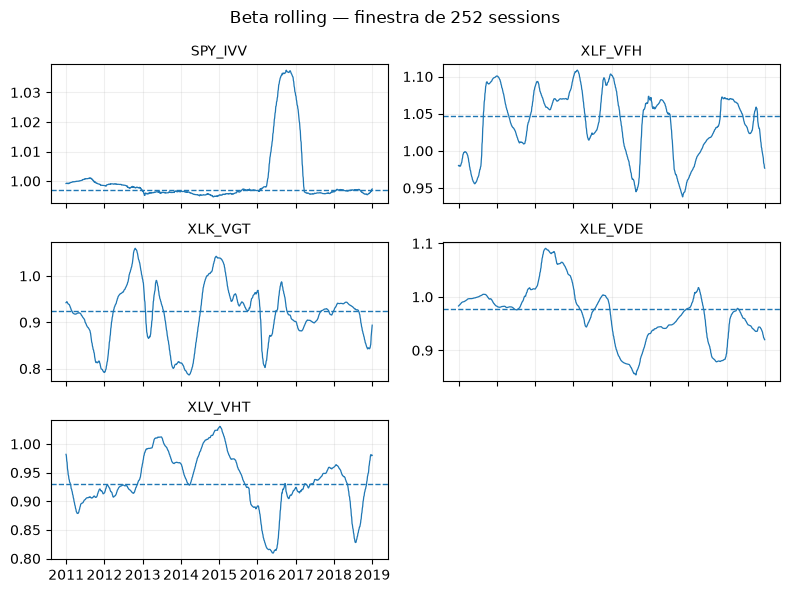

In [23]:
# EVOLUCIÓ DEL BETA ROLLING

fig, axes = plt.subplots(
    3,
    2,
    figsize=(8, 6),
    sharex=True
)

axes = axes.flatten()


for ax, nom_parella in zip(
    axes,
    parelles_candidates.keys()
):

    serie_beta = (
        betas_rolling[
            nom_parella
        ]
    )

    ax.plot(
        serie_beta.index,
        serie_beta,
        linewidth=0.9
    )

    ax.axhline(
        serie_beta.median(),
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        nom_parella,
        fontsize=10
    )

    ax.grid(
        alpha=0.20
    )


axes[-1].axis("off")

fig.suptitle(
    "Beta rolling — finestra de 252 sessions",
    fontsize=12
)

plt.tight_layout()

plt.show()

In [24]:
# RESUM DEL BETA ROLLING

resum_beta_rolling = pd.DataFrame({
    "Mediana": betas_rolling.median(),
    "P10": betas_rolling.quantile(0.10),
    "P90": betas_rolling.quantile(0.90),
    "Min": betas_rolling.min(),
    "Max": betas_rolling.max(),
    "Std": betas_rolling.std()
})

resum_beta_rolling

,Mediana,P10,P90,Min,Max,Std
SPY_IVV,0.996829,0.995523,1.009867,0.994630,1.037525,0.010156
XLF_VFH,1.047323,0.968706,1.091607,0.938099,1.108500,0.043399
XLK_VGT,0.923464,0.813133,1.000887,0.786346,1.059577,0.063529
XLE_VDE,0.976815,0.883234,1.040011,0.854004,1.090729,0.053277
XLV_VHT,0.929876,0.877462,1.003946,0.809577,1.030679,0.049188


## 7. Filosofia de modelització

Els resultats anteriors mostren que diferents parelles poden presentar estructures estadístiques diferents.

Una parella pot funcionar bé sota una relació estàtica:

$$
\log(A_t)
=
\alpha
+
\beta\log(B_t)
+
S_t,
$$

mentre que una altra pot requerir paràmetres variables en el temps:

$$
\log(A_t)
=
\alpha_t
+
\beta_t\log(B_t)
+
S_t.
$$

Per tant, no classificarem prematurament una parella com a "bona" o "dolenta" utilitzant un únic test.

Mantindrem les cinc parelles candidates i estudiarem com es comporten sota diferents models.

Compararem tres famílies principals:

1. **OLS estàtic**, amb $\alpha$ i $\beta$ constants;
2. **OLS rolling**, amb $\alpha_t$ i $\beta_t$ estimats sobre una finestra recent;
3. **Filtre de Kalman**, amb paràmetres que evolucionen dinàmicament.

La metodologia serà:

$$
\text{diagnòstic}
\rightarrow
\text{models de spread}
\rightarrow
\text{train}
\rightarrow
\text{validation}
\rightarrow
\text{test}.
$$

El conjunt de test continuarà completament reservat.

L'objectiu no és trobar alguna configuració que funcioni per força, sinó estudiar si existeixen patrons robustos que es mantinguin fora de mostra.

També acceptarem com a resultat vàlid que una parella no presenti una oportunitat explotable després de costos.

### 7.1. Velocitat de mean reversion

La cointegració estudia si existeix una relació d'equilibri, però per trading també importa la velocitat amb què les desviacions desapareixen.

Modelitzarem aproximadament el spread com un procés autoregressiu:

$$
S_t
=
c
+
\phi S_{t-1}
+
\varepsilon_t.
$$

Si:

$$
0<\phi<1,
$$

el spread presenta mean reversion.

La seva half-life és:

$$
HL
=
\frac{-\ln(2)}
{\ln(\phi)}.
$$

La half-life representa aproximadament el nombre de sessions necessàries perquè una desviació respecte de l'equilibri es redueixi a la meitat.

Una mean reversion molt lenta pot ser estadísticament detectable però poc útil per trading.

In [25]:
# HALF-LIFE DEL SPREAD ESTÀTIC

resultats_half_life = []


for nom_parella, spread in spreads_train.items():

    spread_net = spread.dropna()

    spread_actual = (
        spread_net
        .iloc[1:]
        .to_numpy()
    )

    spread_anterior = (
        spread_net
        .iloc[:-1]
        .to_numpy()
    )


    X = sm.add_constant(
        spread_anterior
    )

    model_ar1 = sm.OLS(
        spread_actual,
        X
    ).fit()


    phi = model_ar1.params[1]


    if 0 < phi < 1:

        half_life = (
            -np.log(2)
            / np.log(phi)
        )

    else:

        half_life = np.nan


    resultats_half_life.append({
        "Parella": nom_parella,
        "Phi": phi,
        "Half_Life_Dies": half_life,
        "R2_AR1": model_ar1.rsquared
    })


half_life_parelles = pd.DataFrame(
    resultats_half_life
)

half_life_parelles

,Parella,Phi,Half_Life_Dies,R2_AR1
0,SPY_IVV,0.942808,11.769698,0.889161
1,XLF_VFH,0.990588,73.297604,0.984694
2,XLK_VGT,0.996006,173.199448,0.989999
3,XLE_VDE,0.999704,2342.722965,0.998048
4,XLV_VHT,0.986471,50.887057,0.974291


In [26]:
# HALF-LIFE PER SUBPERÍODES

resultats_half_life_subperiodes = []


for nom_parella, (
    ticker_A,
    ticker_B
) in parelles_candidates.items():

    for nom_periode, (
        inici,
        final
    ) in subperiodes_train.items():

        y = log_train.loc[
            inici:final,
            ticker_A
        ]

        x = log_train.loc[
            inici:final,
            ticker_B
        ]


        X_ols = sm.add_constant(x)

        model_ols = sm.OLS(
            y,
            X_ols
        ).fit()


        alpha = model_ols.params["const"]
        beta = model_ols.params[ticker_B]


        spread = (
            y
            - alpha
            - beta * x
        ).dropna()


        spread_actual = (
            spread
            .iloc[1:]
            .to_numpy()
        )

        spread_anterior = (
            spread
            .iloc[:-1]
            .to_numpy()
        )


        X_ar = sm.add_constant(
            spread_anterior
        )

        model_ar1 = sm.OLS(
            spread_actual,
            X_ar
        ).fit()


        phi = model_ar1.params[1]


        if 0 < phi < 1:

            half_life = (
                -np.log(2)
                / np.log(phi)
            )

        else:

            half_life = np.nan


        resultats_half_life_subperiodes.append({
            "Parella": nom_parella,
            "Periode": nom_periode,
            "Phi": phi,
            "Half_Life_Dies": half_life
        })


half_life_subperiodes = pd.DataFrame(
    resultats_half_life_subperiodes
)

half_life_subperiodes

,Parella,Periode,Phi,Half_Life_Dies
0,SPY_IVV,2010-2012,0.047171,0.226965
1,SPY_IVV,2013-2015,0.068532,0.258593
2,SPY_IVV,2016-2018,0.938379,10.898273
3,XLF_VFH,2010-2012,0.992021,86.522427
4,XLF_VFH,2013-2015,0.968075,21.363372
5,XLF_VFH,2016-2018,0.976212,28.791137
6,XLK_VGT,2010-2012,0.986182,49.816105
7,XLK_VGT,2013-2015,0.988285,58.819058
8,XLK_VGT,2016-2018,0.982689,39.693606
9,XLE_VDE,2010-2012,0.980119,34.516507


In [27]:
# RESUM DE HALF-LIFE PER PARELLA

resum_half_life = (
    half_life_subperiodes
    .pivot(
        index="Parella",
        columns="Periode",
        values="Half_Life_Dies"
    )
)

resum_half_life

Periode,2010-2012,2013-2015,2016-2018
Parella,,,
SPY_IVV,0.226965,0.258593,10.898273
XLE_VDE,34.516507,49.180964,77.208410
XLF_VFH,86.522427,21.363372,28.791137
XLK_VGT,49.816105,58.819058,39.693606
XLV_VHT,28.857414,22.245710,31.289938


### 7.2. Half-life rolling

Els subperíodes de tres anys han mostrat que la velocitat de mean reversion pot canviar significativament amb el temps.

Per evitar imposar fronteres temporals arbitràries, estimarem la half-life utilitzant una finestra mòbil de 252 sessions:

$$
[t-251,\ldots,t].
$$

Dins de cada finestra:

1. estimarem la relació OLS entre els dos log-preus;
2. construirem el spread residual;
3. estimarem un procés AR(1):

$$
S_t=c+\phi S_{t-1}+\varepsilon_t;
$$

4. calcularem:

$$
HL=
\frac{-\ln(2)}
{\ln(\phi)}.
$$

Aquesta anàlisi és descriptiva.

No utilitzarem la half-life rolling per descartar parelles, sinó per entendre com varia la seva dinàmica al llarg del temps.

In [28]:
# HALF-LIFE ROLLING DE 252 SESSIONS

finestra_half_life = 252

half_life_rolling = pd.DataFrame(
    index=log_train.index
)


for nom_parella, (
    ticker_A,
    ticker_B
) in parelles_candidates.items():

    resultat_parella = pd.Series(
        index=log_train.index,
        dtype=float
    )

    for t in range(
        finestra_half_life - 1,
        len(log_train)
    ):

        finestra = log_train.iloc[
            t - finestra_half_life + 1:
            t + 1
        ]

        y = (
            finestra[ticker_A]
            .to_numpy()
        )

        x = (
            finestra[ticker_B]
            .to_numpy()
        )

        X = np.column_stack([
            np.ones(len(x)),
            x
        ])

        alpha, beta = np.linalg.lstsq(
            X,
            y,
            rcond=None
        )[0]

        spread = (
            y
            - alpha
            - beta * x
        )

        spread_actual = spread[1:]
        spread_anterior = spread[:-1]

        X_ar = np.column_stack([
            np.ones(
                len(spread_anterior)
            ),
            spread_anterior
        ])

        _, phi = np.linalg.lstsq(
            X_ar,
            spread_actual,
            rcond=None
        )[0]

        if 0 < phi < 1:

            half_life = (
                -np.log(2)
                / np.log(phi)
            )

        else:

            half_life = np.nan

        resultat_parella.iloc[t] = (
            half_life
        )

    half_life_rolling[
        nom_parella
    ] = resultat_parella

In [29]:
# RESUM DE LA HALF-LIFE ROLLING

resum_half_life_rolling = pd.DataFrame({
    "Mediana":
        half_life_rolling.median(),

    "P10":
        half_life_rolling.quantile(0.10),

    "P90":
        half_life_rolling.quantile(0.90),

    "Min":
        half_life_rolling.min(),

    "Max":
        half_life_rolling.max(),

    "Pct_HL_Menor_20":
        (
            half_life_rolling < 20
        ).mean(),

    "Pct_HL_Menor_60":
        (
            half_life_rolling < 60
        ).mean(),

    "Pct_Valida":
        half_life_rolling.notna().mean()
})

resum_half_life_rolling

,Mediana,P10,P90,Min,Max,Pct_HL_Menor_20,Pct_HL_Menor_60,Pct_Valida
SPY_IVV,0.297898,0.156448,11.172029,0.057723,18.127748,0.473057,0.473057,0.473057
XLF_VFH,12.846443,4.893501,26.832529,2.971856,148.728651,0.686396,0.878092,0.889134
XLK_VGT,20.183675,8.378248,79.606361,5.228043,839.436673,0.442138,0.756625,0.889134
XLE_VDE,9.274948,4.226927,28.715293,3.210911,582.828140,0.740283,0.867491,0.885601
XLV_VHT,14.244673,6.239893,34.771096,2.321450,248.250720,0.579947,0.878092,0.889134


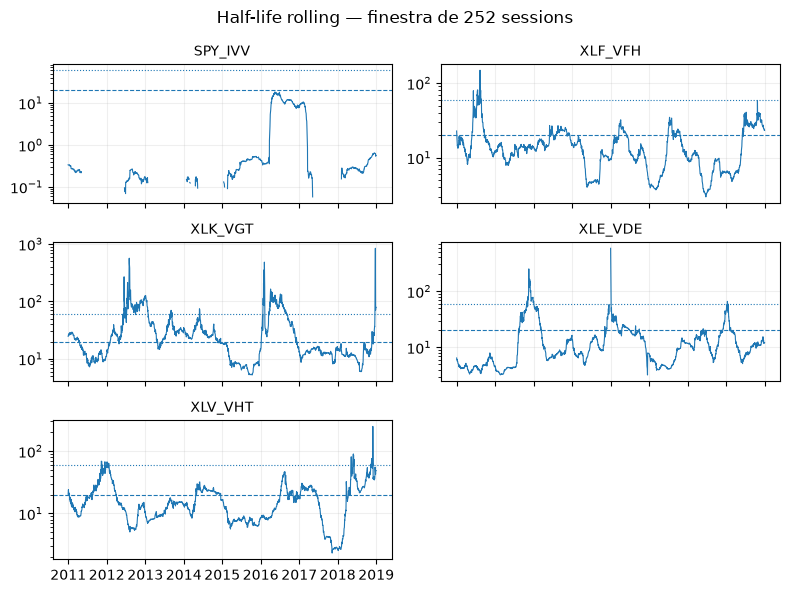

In [30]:
# EVOLUCIÓ DE LA HALF-LIFE ROLLING

fig, axes = plt.subplots(
    3,
    2,
    figsize=(8, 6),
    sharex=True
)

axes = axes.flatten()


for ax, nom_parella in zip(
    axes,
    parelles_candidates.keys()
):

    serie = (
        half_life_rolling[
            nom_parella
        ]
    )

    ax.plot(
        serie.index,
        serie,
        linewidth=0.8
    )

    ax.axhline(
        20,
        linestyle="--",
        linewidth=0.8
    )

    ax.axhline(
        60,
        linestyle=":",
        linewidth=0.8
    )

    ax.set_yscale(
        "log"
    )

    ax.set_title(
        nom_parella,
        fontsize=10
    )

    ax.grid(
        alpha=0.20
    )


axes[-1].axis("off")

fig.suptitle(
    "Half-life rolling — finestra de 252 sessions",
    fontsize=12
)

plt.tight_layout()

plt.show()

## 8. Tres models per estimar el spread

Compararem tres maneres diferents de descriure la relació entre cada parella.

### 1. OLS estàtic

Estimarem una única relació utilitzant les primeres 252 sessions:

$$
\log(A_t)
=
\alpha
+
\beta\log(B_t)
+
S_t.
$$

Després mantindrem $\alpha$ i $\beta$ constants.

Aquest model assumeix que la relació estructural no canvia.

### 2. OLS rolling

Cada dia estimarem:

$$
\alpha_t,\beta_t
$$

utilitzant exclusivament les 252 sessions anteriors.

Això permet que la relació evolucioni gradualment.

### 3. Filtre de Kalman

Estimarem $\alpha_t$ i $\beta_t$ de manera recursiva.

El model assumeix:

$$
\begin{pmatrix}
\alpha_t \\
\beta_t
\end{pmatrix}
=
\begin{pmatrix}
\alpha_{t-1} \\
\beta_{t-1}
\end{pmatrix}
+
\eta_t.
$$

A diferència de l'OLS rolling, el Kalman no elimina bruscament observacions antigues, sinó que actualitza contínuament la seva estimació.

Per fer la comparació de manera justa, els tres models utilitzaran una calibració inicial de 252 sessions.

A partir d'aquest punt, el spread del dia $t$ només utilitzarà informació disponible fins al dia $t-1$.

Per tant:

$$
\boxed{\text{no hi haurà lookahead}}
$$

In [31]:
# OLS ESTÀTIC

finestra_calibracio = 252

spreads_static = pd.DataFrame(
    index=log_train.index
)

parametres_static = {}


for nom_parella, (
    ticker_A,
    ticker_B
) in parelles_candidates.items():

    calibracio = log_train.iloc[
        :finestra_calibracio
    ]

    y_cal = calibracio[ticker_A]

    x_cal = sm.add_constant(
        calibracio[ticker_B]
    )

    model_ols = sm.OLS(
        y_cal,
        x_cal
    ).fit()

    alpha = model_ols.params["const"]
    beta = model_ols.params[ticker_B]

    parametres_static[nom_parella] = {
        "Alpha": alpha,
        "Beta": beta
    }

    spread = (
        log_train[ticker_A]
        - alpha
        - beta * log_train[ticker_B]
    )

    spread.iloc[
        :finestra_calibracio
    ] = np.nan

    spreads_static[
        nom_parella
    ] = spread

In [32]:
# PARÀMETRES DE L'OLS ESTÀTIC

pd.DataFrame(
    parametres_static
).T

,Alpha,Beta
SPY_IVV,0.002623,0.999177
XLF_VFH,-0.823707,0.980182
XLK_VGT,0.537352,0.942307
XLE_VDE,-1.082053,0.982911
XLV_VHT,-0.549002,0.981868


In [33]:
# OLS ROLLING

finestra_rolling = 252

spreads_rolling = pd.DataFrame(
    index=log_train.index
)

betas_rolling_model = pd.DataFrame(
    index=log_train.index
)

alphas_rolling_model = pd.DataFrame(
    index=log_train.index
)


for nom_parella, (
    ticker_A,
    ticker_B
) in parelles_candidates.items():

    spread_parella = pd.Series(
        np.nan,
        index=log_train.index
    )

    alpha_parella = pd.Series(
        np.nan,
        index=log_train.index
    )

    beta_parella = pd.Series(
        np.nan,
        index=log_train.index
    )


    for t in range(
        finestra_rolling,
        len(log_train)
    ):

        finestra = log_train.iloc[
            t - finestra_rolling:t
        ]

        y_hist = (
            finestra[ticker_A]
            .to_numpy()
        )

        x_hist = (
            finestra[ticker_B]
            .to_numpy()
        )

        X = np.column_stack([
            np.ones(
                len(x_hist)
            ),
            x_hist
        ])

        alpha, beta = np.linalg.lstsq(
            X,
            y_hist,
            rcond=None
        )[0]


        y_actual = log_train[
            ticker_A
        ].iloc[t]

        x_actual = log_train[
            ticker_B
        ].iloc[t]


        spread_actual = (
            y_actual
            - alpha
            - beta * x_actual
        )


        spread_parella.iloc[t] = (
            spread_actual
        )

        alpha_parella.iloc[t] = alpha
        beta_parella.iloc[t] = beta


    spreads_rolling[
        nom_parella
    ] = spread_parella

    alphas_rolling_model[
        nom_parella
    ] = alpha_parella

    betas_rolling_model[
        nom_parella
    ] = beta_parella

### 8.3. Filtre de Kalman

Utilitzarem un model de regressió dinàmica:

$$
\log(A_t)
=
\alpha_t
+
\beta_t\log(B_t)
+
\varepsilon_t.
$$

Els paràmetres evolucionen segons:

$$
\alpha_t
=
\alpha_{t-1}
+
\eta_{\alpha,t},
$$

$$
\beta_t
=
\beta_{t-1}
+
\eta_{\beta,t}.
$$

El spread del dia $t$ serà la innovació del filtre abans d'actualitzar els paràmetres:

$$
S_t
=
\log(A_t)
-
\hat{\alpha}_{t|t-1}
-
\hat{\beta}_{t|t-1}\log(B_t).
$$

Aquesta definició és especialment útil perquè representa exactament la desviació inesperada observada respecte de la relació estimada amb informació passada.

In [34]:
# FILTRE DE KALMAN

spreads_kalman = pd.DataFrame(
    index=log_train.index
)

alphas_kalman = pd.DataFrame(
    index=log_train.index
)

betas_kalman = pd.DataFrame(
    index=log_train.index
)


q_alpha = 1e-6
q_beta = 1e-8


Q = np.array([
    [q_alpha, 0.0],
    [0.0, q_beta]
])


for nom_parella, (
    ticker_A,
    ticker_B
) in parelles_candidates.items():

    calibracio = log_train.iloc[
        :finestra_calibracio
    ]

    y_cal = calibracio[
        ticker_A
    ].to_numpy()

    x_cal = calibracio[
        ticker_B
    ].to_numpy()


    X_cal = np.column_stack([
        np.ones(
            len(x_cal)
        ),
        x_cal
    ])


    alpha_inicial, beta_inicial = (
        np.linalg.lstsq(
            X_cal,
            y_cal,
            rcond=None
        )[0]
    )


    residus_inicials = (
        y_cal
        - alpha_inicial
        - beta_inicial * x_cal
    )


    r_observacio = np.var(
        residus_inicials
    )


    estat = np.array([
        alpha_inicial,
        beta_inicial
    ])


    P = np.eye(2) * 0.01


    spread_parella = pd.Series(
        np.nan,
        index=log_train.index
    )

    alpha_parella = pd.Series(
        np.nan,
        index=log_train.index
    )

    beta_parella = pd.Series(
        np.nan,
        index=log_train.index
    )


    for t in range(
        finestra_calibracio,
        len(log_train)
    ):

        # Predicció
        estat_pred = estat.copy()

        P_pred = (
            P
            + Q
        )


        x_actual = log_train[
            ticker_B
        ].iloc[t]

        y_actual = log_train[
            ticker_A
        ].iloc[t]


        H = np.array([
            1.0,
            x_actual
        ])


        # Innovació = spread
        prediccio = (
            H @ estat_pred
        )

        innovacio = (
            y_actual
            - prediccio
        )


        spread_parella.iloc[t] = (
            innovacio
        )

        alpha_parella.iloc[t] = (
            estat_pred[0]
        )

        beta_parella.iloc[t] = (
            estat_pred[1]
        )


        # Actualització
        variancia_innovacio = (
            H
            @ P_pred
            @ H.T
            + r_observacio
        )


        K = (
            P_pred @ H.T
            / variancia_innovacio
        )


        estat = (
            estat_pred
            + K * innovacio
        )


        I = np.eye(2)


        P = (
            (I - np.outer(K, H))
            @ P_pred
        )


    spreads_kalman[
        nom_parella
    ] = spread_parella

    alphas_kalman[
        nom_parella
    ] = alpha_parella

    betas_kalman[
        nom_parella
    ] = beta_parella

In [35]:
# COMPARACIÓ DELS TRES MODELS DE SPREAD

models_spread = {
    "Static": spreads_static,
    "Rolling": spreads_rolling,
    "Kalman": spreads_kalman
}


resum_models_spread = []


for nom_model, df_spreads in models_spread.items():

    for nom_parella in parelles_candidates:

        spread = (
            df_spreads[
                nom_parella
            ]
            .dropna()
        )


        spread_actual = (
            spread
            .iloc[1:]
            .to_numpy()
        )

        spread_anterior = (
            spread
            .iloc[:-1]
            .to_numpy()
        )


        X = np.column_stack([
            np.ones(
                len(spread_anterior)
            ),
            spread_anterior
        ])


        _, phi = np.linalg.lstsq(
            X,
            spread_actual,
            rcond=None
        )[0]


        if 0 < phi < 1:

            half_life = (
                -np.log(2)
                / np.log(phi)
            )

        else:

            half_life = np.nan


        resum_models_spread.append({
            "Parella": nom_parella,
            "Model": nom_model,
            "Std_Spread": spread.std(),
            "Phi": phi,
            "Half_Life": half_life
        })


resum_models_spread = pd.DataFrame(
    resum_models_spread
)

resum_models_spread

,Parella,Model,Std_Spread,Phi,Half_Life
0,SPY_IVV,Static,0.001793,0.957688,16.032767
1,XLF_VFH,Static,0.014853,0.994604,128.104989
2,XLK_VGT,Static,0.019222,0.996086,176.733946
3,XLE_VDE,Static,0.031512,0.999407,1168.596938
4,XLV_VHT,Static,0.009077,0.988170,58.247258
5,SPY_IVV,Rolling,0.000883,0.821211,3.518947
6,XLF_VFH,Rolling,0.006393,0.971920,24.336309
7,XLK_VGT,Rolling,0.010313,0.989387,64.966642
8,XLE_VDE,Rolling,0.005523,0.969315,22.240473
9,XLV_VHT,Rolling,0.006979,0.978493,31.881150


## 9. Capacitat predictiva del z-score

Un spread pot semblar estacionari o presentar una half-life baixa sense que això impliqui necessàriament una oportunitat de trading.

La pregunta rellevant és:

> Quan observem una desviació extrema avui, el spread tendeix realment a corregir-se després?

Construirem un z-score utilitzant només informació passada:

$$
Z_t
=
\frac{
S_t-\hat{\mu}_{t-1}
}{
\hat{\sigma}_{t-1}
}.
$$

Utilitzarem inicialment una finestra fixa de 60 sessions i considerarem una desviació extrema quan:

$$
|Z_t|\geq1.5.
$$

Aquests valors són només una configuració de diagnòstic i no representen encara els paràmetres finals de trading.

Mesurarem la reversió futura com:

$$
R^{rev}_{t,h}
=
-\operatorname{sign}(Z_t)
\frac{
S_{t+h}-S_t
}{
\hat{\sigma}_{t-1}
}.
$$

Aquesta definició fa que:

$$
R^{rev}_{t,h}>0
$$

signifiqui que el spread s'ha mogut en la direcció esperada de mean reversion.

Analitzarem horitzons de:

$$
1,\;5,\;10,\;20
$$

sessions.

In [36]:
# Z-SCORES DELS TRES MODELS

finestra_z_diagnostic = 60

zscores_models = {}
stds_spread_models = {}


for nom_model, df_spreads in models_spread.items():

    mitjana_historica = (
        df_spreads
        .rolling(
            finestra_z_diagnostic
        )
        .mean()
        .shift(1)
    )

    std_historica = (
        df_spreads
        .rolling(
            finestra_z_diagnostic
        )
        .std()
        .shift(1)
    )

    zscores_models[nom_model] = (
        (
            df_spreads
            - mitjana_historica
        )
        / std_historica
    )

    stds_spread_models[
        nom_model
    ] = std_historica

In [37]:
# REVERSIÓ FUTURA DESPRÉS DE Z-SCORES EXTREMS

llindar_z = 1.5

horitzons = [
    1,
    5,
    10,
    20
]

resultats_reversio = []


for nom_model, df_spreads in models_spread.items():

    df_z = (
        zscores_models[
            nom_model
        ]
    )

    df_std = (
        stds_spread_models[
            nom_model
        ]
    )


    for nom_parella in parelles_candidates:

        spread = (
            df_spreads[
                nom_parella
            ]
        )

        z = (
            df_z[
                nom_parella
            ]
        )

        sigma = (
            df_std[
                nom_parella
            ]
        )


        for horitzo in horitzons:

            spread_futur = (
                spread
                .shift(
                    -horitzo
                )
            )


            valid = (
                z.abs()
                >= llindar_z
            )

            valid &= (
                spread.notna()
                & spread_futur.notna()
                & z.notna()
                & sigma.notna()
                & (sigma > 0)
            )


            z_valid = z[
                valid
            ]

            canvi_spread = (
                spread_futur[valid]
                - spread[valid]
            )


            reversio_normalitzada = (
                -np.sign(
                    z_valid
                )
                * canvi_spread
                / sigma[valid]
            )


            resultats_reversio.append({

                "Parella":
                    nom_parella,

                "Model":
                    nom_model,

                "Horitzo_Dies":
                    horitzo,

                "N_Observacions":
                    len(
                        reversio_normalitzada
                    ),

                "Taxa_Reversio":
                    (
                        reversio_normalitzada
                        > 0
                    ).mean(),

                "Reversio_Mitjana":
                    reversio_normalitzada.mean(),

                "Reversio_Mediana":
                    reversio_normalitzada.median(),

                "Z_Abs_Mediana":
                    z_valid.abs().median()
            })


resum_reversio = pd.DataFrame(
    resultats_reversio
)

resum_reversio

,Parella,Model,Horitzo_Dies,N_Observacions,Taxa_Reversio,Reversio_Mitjana,Reversio_Mediana,Z_Abs_Mediana
0,SPY_IVV,Static,1,271,0.885609,1.973240,1.802048,1.942766
1,SPY_IVV,Static,5,270,0.900000,2.121577,1.666513,1.940862
2,SPY_IVV,Static,10,267,0.895131,2.209245,1.612453,1.932256
3,SPY_IVV,Static,20,265,0.890566,2.448489,1.798482,1.923045
4,XLF_VFH,Static,1,618,0.555016,0.076326,0.052751,1.961736
5,XLF_VFH,Static,5,618,0.551780,0.096886,0.126336,1.961736
6,XLF_VFH,Static,10,618,0.558252,0.058989,0.142449,1.961736
7,XLF_VFH,Static,20,617,0.520259,-0.096448,0.082936,1.961985
8,XLK_VGT,Static,1,653,0.509954,0.017153,0.003272,1.923983
9,XLK_VGT,Static,5,649,0.469954,-0.046116,-0.045794,1.926580


In [38]:
# RESUM DE REVERSIÓ A 5 I 20 DIES

resum_reversio_clau = (
    resum_reversio[
        resum_reversio[
            "Horitzo_Dies"
        ].isin([
            5,
            20
        ])
    ]
    [
        [
            "Parella",
            "Model",
            "Horitzo_Dies",
            "N_Observacions",
            "Taxa_Reversio",
            "Reversio_Mitjana",
            "Reversio_Mediana"
        ]
    ]
    .sort_values(
        [
            "Parella",
            "Horitzo_Dies",
            "Model"
        ]
    )
    .reset_index(
        drop=True
    )
)

resum_reversio_clau

,Parella,Model,Horitzo_Dies,N_Observacions,Taxa_Reversio,Reversio_Mitjana,Reversio_Mediana
0,SPY_IVV,Kalman,5,228,0.951754,2.332640,2.133142
1,SPY_IVV,Rolling,5,310,0.738710,1.499277,1.310946
2,SPY_IVV,Static,5,270,0.900000,2.121577,1.666513
3,SPY_IVV,Kalman,20,222,0.972973,2.392064,2.086286
4,SPY_IVV,Rolling,20,306,0.751634,1.548534,1.120301
5,SPY_IVV,Static,20,265,0.890566,2.448489,1.798482
6,XLE_VDE,Kalman,5,277,0.927798,1.752123,1.641004
7,XLE_VDE,Rolling,5,531,0.596987,0.196440,0.170682
8,XLE_VDE,Static,5,609,0.558292,0.129695,0.101840
9,XLE_VDE,Kalman,20,276,0.945652,2.096683,2.051682


### 9.1. Interpretació inicial de la capacitat predictiva

Els resultats mostren diferències importants entre parelles i models.

SPY–IVV presenta una reversió molt forta sota els tres models.

XLE–VDE i XLV–VHT mostren una reversió especialment interessant a horitzons d'aproximadament 20 sessions quan utilitzem una relació rolling.

En canvi, XLF–VFH i XLK–VGT presenten poca capacitat predictiva a curt termini sota els models Static i Rolling.

Els resultats de Kalman són molt superiors per totes les parelles. Tanmateix, cal interpretar-los amb prudència.

El spread Kalman és una innovació de predicció. Després d'una innovació extrema, el filtre actualitza $\alpha_t$ i $\beta_t$, de manera que les innovacions futures tendeixen mecànicament a tornar prop de zero.

Per tant:

$$
\text{reversió de la innovació}
\neq
\text{necessàriament convergència explotable dels preus}.
$$

El següent diagnòstic mantindrà congelats els paràmetres observats en el moment del senyal i comptarà només el primer dia de cada episodi extrem.

### 9.2. Reversió amb paràmetres congelats

Per comprovar si la convergència prové realment dels preus, mantindrem congelats els paràmetres estimats en el moment del senyal.

Per una observació extrema en $t$:

$$
S_t
=
\log(A_t)
-
\hat{\alpha}_t
-
\hat{\beta}_t\log(B_t).
$$

El spread futur es calcularà amb els mateixos paràmetres:

$$
S_{t+h}^{frozen}
=
\log(A_{t+h})
-
\hat{\alpha}_t
-
\hat{\beta}_t\log(B_{t+h}).
$$

Aquesta metodologia evita atribuir al mercat una reversió que en realitat prové de l'actualització posterior del model.

A més, només comptarem el primer dia de cada episodi en què el z-score travessa el llindar extrem.

In [39]:
# PARÀMETRES DELS TRES MODELS

alphas_static_model = pd.DataFrame(
    index=log_train.index
)

betas_static_model = pd.DataFrame(
    index=log_train.index
)


for nom_parella in parelles_candidates:

    alphas_static_model[nom_parella] = (
        parametres_static[
            nom_parella
        ]["Alpha"]
    )

    betas_static_model[nom_parella] = (
        parametres_static[
            nom_parella
        ]["Beta"]
    )


alphas_models = {
    "Static": alphas_static_model,
    "Rolling": alphas_rolling_model,
    "Kalman": alphas_kalman
}


betas_models = {
    "Static": betas_static_model,
    "Rolling": betas_rolling_model,
    "Kalman": betas_kalman
}

In [40]:
# REVERSIÓ AMB PARÀMETRES CONGELATS

llindar_z_frozen = 1.5

horitzons_frozen = [
    1,
    5,
    10,
    20
]

resultats_frozen = []


for nom_model in models_spread:

    df_z = zscores_models[
        nom_model
    ]

    df_std = stds_spread_models[
        nom_model
    ]

    df_alpha = alphas_models[
        nom_model
    ]

    df_beta = betas_models[
        nom_model
    ]


    for nom_parella, (
        ticker_A,
        ticker_B
    ) in parelles_candidates.items():

        z = df_z[nom_parella]
        sigma = df_std[nom_parella]

        alpha = df_alpha[nom_parella]
        beta = df_beta[nom_parella]

        z_anterior = z.shift(1)


        # Primer dia de cada episodi extrem
        entrada_extrema = (
            z.abs()
            >= llindar_z_frozen
        )

        entrada_extrema &= (
            z_anterior.abs()
            < llindar_z_frozen
        ) | (
            z_anterior.isna()
        ) | (
            np.sign(z)
            != np.sign(z_anterior)
        )


        spread_entrada = (
            log_train[ticker_A]
            - alpha
            - beta
            * log_train[ticker_B]
        )


        for horitzo in horitzons_frozen:

            spread_futur_congelat = (
                log_train[
                    ticker_A
                ]
                .shift(
                    -horitzo
                )
                - alpha
                - beta
                * log_train[
                    ticker_B
                ]
                .shift(
                    -horitzo
                )
            )


            valid = (
                entrada_extrema
                & z.notna()
                & sigma.notna()
                & (sigma > 0)
                & alpha.notna()
                & beta.notna()
                & spread_futur_congelat.notna()
            )


            reversio = (
                -np.sign(
                    z[valid]
                )
                * (
                    spread_futur_congelat[valid]
                    - spread_entrada[valid]
                )
                / sigma[valid]
            )


            resultats_frozen.append({

                "Parella":
                    nom_parella,

                "Model":
                    nom_model,

                "Horitzo_Dies":
                    horitzo,

                "N_Episodis":
                    len(reversio),

                "Taxa_Reversio":
                    (
                        reversio > 0
                    ).mean(),

                "Reversio_Mitjana":
                    reversio.mean(),

                "Reversio_Mediana":
                    reversio.median()
            })


resum_frozen = pd.DataFrame(
    resultats_frozen
)

resum_frozen

,Parella,Model,Horitzo_Dies,N_Episodis,Taxa_Reversio,Reversio_Mitjana,Reversio_Mediana
0,SPY_IVV,Static,1,219,0.917808,2.183263,2.015214
1,SPY_IVV,Static,5,218,0.940367,2.146521,1.757037
2,SPY_IVV,Static,10,216,0.939815,2.284221,1.890735
3,SPY_IVV,Static,20,214,0.925234,2.453934,1.913575
4,XLF_VFH,Static,1,161,0.639752,0.139958,0.125708
5,XLF_VFH,Static,5,161,0.577640,0.187461,0.166020
6,XLF_VFH,Static,10,161,0.552795,0.193981,0.149705
7,XLF_VFH,Static,20,160,0.525000,-0.029808,0.114125
8,XLK_VGT,Static,1,124,0.572581,0.030040,0.062395
9,XLK_VGT,Static,5,124,0.451613,0.035950,-0.045662


In [41]:
# RESUM FROZEN A 5 I 20 DIES

resum_frozen_clau = (
    resum_frozen[
        resum_frozen[
            "Horitzo_Dies"
        ].isin([
            5,
            20
        ])
    ]
    .sort_values(
        [
            "Parella",
            "Horitzo_Dies",
            "Model"
        ]
    )
    .reset_index(
        drop=True
    )
)

resum_frozen_clau

,Parella,Model,Horitzo_Dies,N_Episodis,Taxa_Reversio,Reversio_Mitjana,Reversio_Mediana
0,SPY_IVV,Kalman,5,224,0.866071,1.216327,1.090430
1,SPY_IVV,Rolling,5,202,0.891089,2.076039,1.814832
2,SPY_IVV,Static,5,218,0.940367,2.146521,1.757037
3,SPY_IVV,Kalman,20,218,0.807339,1.212749,1.060098
4,SPY_IVV,Rolling,20,198,0.909091,2.352634,1.903447
5,SPY_IVV,Static,20,214,0.925234,2.453934,1.913575
6,XLE_VDE,Kalman,5,198,0.545455,0.235290,0.177588
7,XLE_VDE,Rolling,5,148,0.587838,0.137280,0.128785
8,XLE_VDE,Static,5,149,0.570470,0.205424,0.101840
9,XLE_VDE,Kalman,20,197,0.568528,0.418594,0.587345


### 9.3. Conclusions de la reversió amb paràmetres congelats

Congelar els paràmetres en el moment del senyal redueix considerablement la reversió aparent del model de Kalman.

Això confirma que part dels resultats inicials provenien de l'actualització posterior de la relació estimada i no exclusivament de la convergència dels preus.

Els resultats més destacats són:

- **SPY–IVV:** reversió molt forta i consistent sota els tres models.
- **XLE–VDE:** reversió moderada, especialment a 20 sessions.
- **XLV–VHT:** reversió moderada a horitzons llargs.
- **XLF–VFH:** poca capacitat predictiva malgrat la cointegració global.
- **XLK–VGT:** cap evidència clara de mean reversion; a 20 sessions apareix continuació del moviment.

Per tant:

$$
\boxed{
\text{cointegració}
\neq
\text{capacitat predictiva}
\neq
\text{rendibilitat després de costos}
}
$$

El següent pas serà convertir aquestes desviacions en operacions reals, amb una sola posició oberta per parella, execució retardada i costos de transacció.

## 10. Primer backtest sobre dades reals

Construirem un primer backtest comú per les cinc parelles i els tres models de spread:

$$
5\ parelles
\times
3\ models
=
15\ estratègies.
$$

Utilitzarem inicialment una única regla:

$$
|Z_t|\geq1.5
\quad\Rightarrow\quad
\text{entrada}.
$$

Si:

$$
Z_t<-1.5,
$$

obrirem una posició **long spread**.

Si:

$$
Z_t>1.5,
$$

obrirem una posició **short spread**.

La posició es tancarà quan el z-score torni a travessar zero.

El senyal observat al dia $t$ només podrà generar una posició a partir del període següent, evitant lookahead.

### Hedge ratio congelat

Quan obrim una operació congelarem el $\beta$ disponible en aquell moment.

Els pesos seran:

$$
w_A
=
\frac{p}{1+|\beta|}
$$

i

$$
w_B
=
-\frac{p\beta}{1+|\beta|},
$$

on:

$$
p\in\{-1,0,1\}.
$$

Això manté una exposició bruta aproximadament igual a 1 mentre existeix una posició.

El hedge ratio no canviarà fins que l'operació es tanqui.

### Costos

Utilitzarem inicialment un cost proporcional de:

$$
0.1\%
$$

per unitat de turnover.

Per tant, entrar i sortir d'una posició amb exposició bruta 1 té un cost aproximat de:

$$
0.2\%
$$

round-trip.

Aquest és encara un model simplificat de costos i posteriorment estudiarem la seva sensibilitat.

En aquest primer backtest assumirem també:

$$
r_f=0.
$$

L'objectiu encara no és seleccionar el model final, sinó comprovar si la reversió estadística es transforma en rendibilitat econòmica.

In [43]:
# BACKTEST D'UNA PARELLA I UN MODEL

def backtest_parella_model(
    nom_parella,
    nom_model,
    z_entrada=1.5,
    z_sortida=0.0,
    cost_transaccio=0.001,
    capital_inicial=10_000
):

    ticker_A, ticker_B = (
        parelles_candidates[
            nom_parella
        ]
    )

    z = (
        zscores_models[
            nom_model
        ][
            nom_parella
        ]
        .copy()
    )

    beta_estimada = (
        betas_models[
            nom_model
        ][
            nom_parella
        ]
        .copy()
    )


    retorn_A = (
        train[ticker_A]
        .pct_change()
        .fillna(0)
    )

    retorn_B = (
        train[ticker_B]
        .pct_change()
        .fillna(0)
    )


    # ------------------------------------------
    # SENYALS
    # ------------------------------------------

    senyal = pd.Series(
        0.0,
        index=train.index
    )

    beta_senyal = pd.Series(
        np.nan,
        index=train.index
    )


    posicio_actual = 0
    beta_entrada = np.nan


    for t in range(
        len(train)
    ):

        z_t = z.iloc[t]

        beta_t = (
            beta_estimada.iloc[t]
        )


        if (
            not np.isfinite(z_t)
            or
            not np.isfinite(beta_t)
        ):

            senyal.iloc[t] = (
                posicio_actual
            )

            if posicio_actual != 0:

                beta_senyal.iloc[t] = (
                    beta_entrada
                )

            continue


        # Sense posició
        if posicio_actual == 0:

            if z_t > z_entrada:

                posicio_actual = -1
                beta_entrada = beta_t

            elif z_t < -z_entrada:

                posicio_actual = 1
                beta_entrada = beta_t


        # Long spread
        elif posicio_actual == 1:

            if z_t >= -z_sortida:

                posicio_actual = 0
                beta_entrada = np.nan


        # Short spread
        elif posicio_actual == -1:

            if z_t <= z_sortida:

                posicio_actual = 0
                beta_entrada = np.nan


        senyal.iloc[t] = (
            posicio_actual
        )


        if posicio_actual != 0:

            beta_senyal.iloc[t] = (
                beta_entrada
            )


    # ------------------------------------------
    # EXECUCIÓ AL PERÍODE SEGÜENT
    # ------------------------------------------

    posicio = (
        senyal
        .shift(1)
        .fillna(0)
    )

    beta_trading = (
        beta_senyal
        .shift(1)
    )


    # ------------------------------------------
    # PESOS
    # ------------------------------------------

    beta_abs = (
        beta_trading.abs()
    )

    denominador = (
        1
        + beta_abs
    )


    pes_A = (
        posicio
        / denominador
    )

    pes_B = (
        -posicio
        * beta_trading
        / denominador
    )


    pes_A = (
        pes_A
        .fillna(0)
    )

    pes_B = (
        pes_B
        .fillna(0)
    )


    # ------------------------------------------
    # RETORN BRUT
    # ------------------------------------------

    retorn_brut = (
        pes_A * retorn_A
        + pes_B * retorn_B
    )


    # ------------------------------------------
    # TURNOVER
    # ------------------------------------------

    turnover = (
        pes_A
        .diff()
        .abs()
        .fillna(
            abs(pes_A.iloc[0])
        )
        +
        pes_B
        .diff()
        .abs()
        .fillna(
            abs(pes_B.iloc[0])
        )
    )


    costos = (
        cost_transaccio
        * turnover
    )


    retorn_net = (
        retorn_brut
        - costos
    )


    # ------------------------------------------
    # PERÍODE REAL DEL BACKTEST
    # ------------------------------------------

    inici_backtest = (
        z.first_valid_index()
    )


    retorn_net = (
        retorn_net.loc[
            inici_backtest:
        ]
    )

    retorn_brut = (
        retorn_brut.loc[
            inici_backtest:
        ]
    )

    costos = (
        costos.loc[
            inici_backtest:
        ]
    )

    turnover = (
        turnover.loc[
            inici_backtest:
        ]
    )

    posicio = (
        posicio.loc[
            inici_backtest:
        ]
    )

    pes_A = (
        pes_A.loc[
            inici_backtest:
        ]
    )

    pes_B = (
        pes_B.loc[
            inici_backtest:
        ]
    )

    beta_trading = (
        beta_trading.loc[
            inici_backtest:
        ]
    )

    z_backtest = (
        z.loc[
            inici_backtest:
        ]
    )


    # ------------------------------------------
    # CAPITAL
    # ------------------------------------------

    capital = (
        capital_inicial
        * (
            1 + retorn_net
        ).cumprod()
    )


    # ------------------------------------------
    # RENDIBILITAT ANUAL
    # ------------------------------------------

    n_sessions = len(
        retorn_net
    )


    rendibilitat_anual = (
        (
            capital.iloc[-1]
            / capital_inicial
        )
        ** (
            252
            / n_sessions
        )
        - 1
    )


    # ------------------------------------------
    # VOLATILITAT I SHARPE
    # ------------------------------------------

    volatilitat_anual = (
        retorn_net.std()
        * np.sqrt(252)
    )


    if retorn_net.std() > 0:

        sharpe = (
            retorn_net.mean()
            / retorn_net.std()
            * np.sqrt(252)
        )

    else:

        sharpe = np.nan


    # ------------------------------------------
    # DRAWDOWN
    # ------------------------------------------

    maxim_capital = (
        capital.cummax()
    )

    drawdown = (
        capital
        / maxim_capital
        - 1
    )

    max_drawdown = (
        drawdown.min()
    )


    # ------------------------------------------
    # OPERACIONS
    # ------------------------------------------

    posicio_anterior = (
        posicio
        .shift(1)
        .fillna(0)
    )

    entrades = (
        (posicio != 0)
        &
        (posicio_anterior == 0)
    )

    operacions = int(
        entrades.sum()
    )


    # ------------------------------------------
    # TEMPS EN MERCAT
    # ------------------------------------------

    pct_temps_mercat = (
        (posicio != 0)
        .mean()
    )


    # ------------------------------------------
    # RESULTATS
    # ------------------------------------------

    metrics = {

        "Parella":
            nom_parella,

        "Model":
            nom_model,

        "Rendibilitat_Anual":
            rendibilitat_anual,

        "Volatilitat_Anual":
            volatilitat_anual,

        "Sharpe":
            sharpe,

        "Max_Drawdown":
            max_drawdown,

        "Operacions":
            operacions,

        "Pct_Temps_Mercat":
            pct_temps_mercat,

        "Turnover_Total":
            turnover.sum(),

        "Cost_Total":
            costos.sum(),

        "Capital_Final":
            capital.iloc[-1]
    }


    detall = pd.DataFrame({

        "Z":
            z_backtest,

        "Posicio":
            posicio,

        "Beta_Trading":
            beta_trading,

        "Pes_A":
            pes_A,

        "Pes_B":
            pes_B,

        "Retorn_Brut":
            retorn_brut,

        "Cost":
            costos,

        "Retorn_Net":
            retorn_net,

        "Capital":
            capital,

        "Drawdown":
            drawdown
    })


    return metrics, detall

In [44]:
# BACKTEST DE LES 15 ESTRATÈGIES

models_backtest = [
    "Static",
    "Rolling",
    "Kalman"
]


resultats_backtest_train = []

detalls_backtest_train = {}


for nom_parella in parelles_candidates:

    for nom_model in models_backtest:

        metrics, detall = (
            backtest_parella_model(
                nom_parella=nom_parella,
                nom_model=nom_model,
                z_entrada=1.5,
                z_sortida=0.0,
                cost_transaccio=0.001
            )
        )


        resultats_backtest_train.append(
            metrics
        )


        detalls_backtest_train[
            (
                nom_parella,
                nom_model
            )
        ] = detall


resultats_backtest_train = pd.DataFrame(
    resultats_backtest_train
)

resultats_backtest_train

,Parella,Model,Rendibilitat_Anual,Volatilitat_Anual,Sharpe,Max_Drawdown,Operacions,Pct_Temps_Mercat,Turnover_Total,Cost_Total,Capital_Final
0,SPY_IVV,Static,-0.035538,0.005878,-6.152118,-0.244433,180,0.246414,360.0,0.360,7555.670547
1,SPY_IVV,Rolling,-0.030814,0.005551,-5.635564,-0.215288,158,0.286885,316.0,0.316,7847.121952
2,SPY_IVV,Kalman,-0.034567,0.005443,-6.460366,-0.238522,162,0.095799,324.0,0.324,7614.780182
3,XLF_VFH,Static,-0.007066,0.011248,-0.624831,-0.056200,49,0.710041,98.0,0.098,9465.518746
4,XLF_VFH,Rolling,-0.009264,0.009880,-0.937048,-0.070566,40,0.725922,80.0,0.080,9304.462036
5,XLF_VFH,Kalman,-0.015030,0.008755,-1.725376,-0.111454,91,0.452357,181.0,0.181,8893.137255
6,XLK_VGT,Static,-0.009010,0.011449,-0.784801,-0.070043,35,0.709016,69.0,0.069,9322.935643
7,XLK_VGT,Rolling,-0.013312,0.011859,-1.124094,-0.104384,45,0.685963,89.0,0.089,9013.994293
8,XLK_VGT,Kalman,-0.017639,0.010466,-1.695146,-0.133816,83,0.460041,165.0,0.165,8712.260238
9,XLE_VDE,Static,-0.009517,0.009252,-1.028902,-0.072114,50,0.677766,99.0,0.099,9286.072819


In [45]:
# RESUM DEL BACKTEST EN TRAIN

resum_backtest_train = (
    resultats_backtest_train[
        [
            "Parella",
            "Model",
            "Rendibilitat_Anual",
            "Volatilitat_Anual",
            "Sharpe",
            "Max_Drawdown",
            "Operacions",
            "Pct_Temps_Mercat",
            "Turnover_Total"
        ]
    ]
    .sort_values(
        [
            "Parella",
            "Model"
        ]
    )
    .reset_index(
        drop=True
    )
)

resum_backtest_train

,Parella,Model,Rendibilitat_Anual,Volatilitat_Anual,Sharpe,Max_Drawdown,Operacions,Pct_Temps_Mercat,Turnover_Total
0,SPY_IVV,Kalman,-0.034567,0.005443,-6.460366,-0.238522,162,0.095799,324.0
1,SPY_IVV,Rolling,-0.030814,0.005551,-5.635564,-0.215288,158,0.286885,316.0
2,SPY_IVV,Static,-0.035538,0.005878,-6.152118,-0.244433,180,0.246414,360.0
3,XLE_VDE,Kalman,-0.029294,0.007739,-3.837597,-0.205709,138,0.340164,276.0
4,XLE_VDE,Rolling,-0.009335,0.009609,-0.971274,-0.070238,50,0.641393,99.0
5,XLE_VDE,Static,-0.009517,0.009252,-1.028902,-0.072114,50,0.677766,99.0
6,XLF_VFH,Kalman,-0.015030,0.008755,-1.725376,-0.111454,91,0.452357,181.0
7,XLF_VFH,Rolling,-0.009264,0.009880,-0.937048,-0.070566,40,0.725922,80.0
8,XLF_VFH,Static,-0.007066,0.011248,-0.624831,-0.056200,49,0.710041,98.0
9,XLK_VGT,Kalman,-0.017639,0.010466,-1.695146,-0.133816,83,0.460041,165.0


### 10.1. Rendibilitat bruta i impacte dels costos

El primer backtest presenta rendibilitats negatives en totes les combinacions.

Abans de modificar els paràmetres del senyal, separarem dues qüestions:

$$
\text{el senyal genera alpha?}
$$

i

$$
\text{els costos permeten capturar-la?}
$$

Calcularem la rendibilitat que hauria produït exactament la mateixa estratègia sense costos de transacció i la compararem amb la rendibilitat neta.

Això permetrà distingir entre:

$$
\text{estratègia sense edge}
$$

i

$$
\text{estratègia amb edge però massa costosa d'executar}.
$$

In [46]:
# RENDIBILITAT BRUTA VS NETA

comparacio_costos = []


for (
    nom_parella,
    nom_model
), detall in detalls_backtest_train.items():

    retorn_brut = (
        detall["Retorn_Brut"]
        .fillna(0)
    )

    retorn_net = (
        detall["Retorn_Net"]
        .fillna(0)
    )

    n_sessions = len(
        detall
    )


    capital_brut = (
        10_000
        * (
            1 + retorn_brut
        ).cumprod()
    )

    capital_net = (
        10_000
        * (
            1 + retorn_net
        ).cumprod()
    )


    rend_anual_bruta = (
        (
            capital_brut.iloc[-1]
            / 10_000
        )
        ** (
            252
            / n_sessions
        )
        - 1
    )


    rend_anual_neta = (
        (
            capital_net.iloc[-1]
            / 10_000
        )
        ** (
            252
            / n_sessions
        )
        - 1
    )


    fila_original = (
        resultats_backtest_train[
            (
                resultats_backtest_train["Parella"]
                == nom_parella
            )
            &
            (
                resultats_backtest_train["Model"]
                == nom_model
            )
        ]
        .iloc[0]
    )


    comparacio_costos.append({

        "Parella":
            nom_parella,

        "Model":
            nom_model,

        "Rend_Anual_Bruta":
            rend_anual_bruta,

        "Rend_Anual_Neta":
            rend_anual_neta,

        "Drag_Costos_Anual":
            (
                rend_anual_bruta
                - rend_anual_neta
            ),

        "Operacions":
            fila_original[
                "Operacions"
            ],

        "Turnover":
            fila_original[
                "Turnover_Total"
            ]
    })


comparacio_costos = pd.DataFrame(
    comparacio_costos
)

comparacio_costos.sort_values(
    "Rend_Anual_Bruta",
    ascending=False
).reset_index(
    drop=True
)

,Parella,Model,Rend_Anual_Bruta,Rend_Anual_Neta,Drag_Costos_Anual,Operacions,Turnover
0,SPY_IVV,Static,0.010360,-0.035538,0.045898,180,360.0
1,SPY_IVV,Rolling,0.009555,-0.030814,0.040369,158,316.0
2,XLF_VFH,Kalman,0.008266,-0.015030,0.023296,91,181.0
3,XLV_VHT,Kalman,0.007951,-0.019016,0.026968,105,210.0
4,SPY_IVV,Kalman,0.006686,-0.034567,0.041253,162,324.0
5,XLV_VHT,Static,0.006233,-0.007832,0.014065,55,109.0
6,XLE_VDE,Kalman,0.005930,-0.029294,0.035225,138,276.0
7,XLF_VFH,Static,0.005581,-0.007066,0.012647,49,98.0
8,XLV_VHT,Rolling,0.004545,-0.009496,0.014042,55,109.0
9,XLK_VGT,Kalman,0.003521,-0.017639,0.021160,83,165.0


### 10.2. Sensibilitat als costos de transacció

Els resultats anteriors mostren que diverses estratègies presenten rendibilitat bruta positiva, però els costos de transacció eliminen aquest edge.

Abans de modificar els senyals estudiarem la sensibilitat a diferents nivells de cost.

Considerarem:

$$
0,\ 0.5,\ 1,\ 2,\ 5,\ 10
$$

basis points per unitat de turnover, on:

$$
1\text{ bp}=0.01\%.
$$

També estimarem el **break-even cost**:

$$
c^*
$$

definit com el cost màxim per unitat de turnover que fa que la rendibilitat final de l'estratègia sigui aproximadament zero.

Si:

$$
c<c^*,
$$

l'estratègia és rendible.

Si:

$$
c>c^*,
$$

els costos eliminen l'edge brut.

In [47]:
# SENSIBILITAT ALS COSTOS

costos_bps = [
    0.0,
    0.5,
    1.0,
    2.0,
    5.0,
    10.0
]

resultats_sensibilitat_costos = []


for (
    nom_parella,
    nom_model
), detall in detalls_backtest_train.items():

    retorn_brut = (
        detall["Retorn_Brut"]
        .fillna(0)
    )

    pes_A = (
        detall["Pes_A"]
        .fillna(0)
    )

    pes_B = (
        detall["Pes_B"]
        .fillna(0)
    )


    turnover = (
        pes_A.diff().abs().fillna(
            abs(pes_A.iloc[0])
        )
        +
        pes_B.diff().abs().fillna(
            abs(pes_B.iloc[0])
        )
    )


    for cost_bps in costos_bps:

        cost_decimal = (
            cost_bps
            / 10_000
        )


        retorn_net = (
            retorn_brut
            - cost_decimal * turnover
        )


        capital = (
            10_000
            * (
                1 + retorn_net
            ).cumprod()
        )


        n_sessions = len(
            retorn_net
        )


        rendibilitat_anual = (
            (
                capital.iloc[-1]
                / 10_000
            )
            ** (
                252
                / n_sessions
            )
            - 1
        )


        resultats_sensibilitat_costos.append({

            "Parella":
                nom_parella,

            "Model":
                nom_model,

            "Cost_bps":
                cost_bps,

            "Rendibilitat_Anual":
                rendibilitat_anual
        })


sensibilitat_costos = pd.DataFrame(
    resultats_sensibilitat_costos
)

sensibilitat_costos

,Parella,Model,Cost_bps,Rendibilitat_Anual
0,SPY_IVV,Static,0.0,0.010360
1,SPY_IVV,Static,0.5,0.008015
2,SPY_IVV,Static,1.0,0.005676
3,SPY_IVV,Static,2.0,0.001013
4,SPY_IVV,Static,5.0,-0.012850
...,...,...,...,...
85,XLV_VHT,Kalman,0.5,0.006586
86,XLV_VHT,Kalman,1.0,0.005223
87,XLV_VHT,Kalman,2.0,0.002501
88,XLV_VHT,Kalman,5.0,-0.005621


In [48]:
# TAULA DE RENDIBILITAT SEGONS COST

taula_sensibilitat_costos = (
    sensibilitat_costos
    .pivot(
        index=[
            "Parella",
            "Model"
        ],
        columns="Cost_bps",
        values="Rendibilitat_Anual"
    )
)

taula_sensibilitat_costos.columns = [
    f"{cost:g}_bps"
    for cost in taula_sensibilitat_costos.columns
]

taula_sensibilitat_costos

0_bps   0.5_bps     1_bps     2_bps     5_bps    10_bps
Parella Model                                                              
SPY_IVV Kalman   0.006686  0.004583  0.002485 -0.001700 -0.014151 -0.034567
        Rolling  0.009555  0.007499  0.005446  0.001353 -0.010830 -0.030814
        Static   0.010360  0.008015  0.005676  0.001013 -0.012850 -0.035538
XLE_VDE Kalman   0.005930  0.004140  0.002353 -0.001212 -0.011835 -0.029294
        Rolling  0.003412  0.002771  0.002131  0.000851 -0.002980 -0.009335
        Static   0.003229  0.002588  0.001947  0.000667 -0.003163 -0.009517
XLF_VFH Kalman   0.008266  0.007089  0.005913  0.003565 -0.003447 -0.015030
        Rolling  0.001026  0.000509 -0.000008 -0.001040 -0.004131 -0.009264
        Static   0.005581  0.004945  0.004310  0.003040 -0.000761 -0.007066
XLK_VGT Kalman   0.003521  0.002452  0.001385 -0.000746 -0.007113 -0.017639
        Rolling -0.001905 -0.002478 -0.003051 -0.004196 -0.007623 -0.013312
        Static  -0.000139 -0.000584 -0.001029 -0.001919 -0.004583 -0.009010
XLV_VHT Kalman   0.007951  0.006586  0.005223  0.002501 -0.005621 -0.019016
        Rolling  0.004545  0.003839  0.003133  0.001722 -0.002499 -0.009496
        Static   0.006233  0.005525  0.004818  0.003405 -0.000823 -0.007832

In [49]:
# BREAK-EVEN COST

resultats_break_even = []


for (
    nom_parella,
    nom_model
), detall in detalls_backtest_train.items():

    retorn_brut = (
        detall["Retorn_Brut"]
        .fillna(0)
        .to_numpy()
    )

    pes_A = (
        detall["Pes_A"]
        .fillna(0)
    )

    pes_B = (
        detall["Pes_B"]
        .fillna(0)
    )


    turnover = (
        pes_A.diff().abs().fillna(
            abs(pes_A.iloc[0])
        )
        +
        pes_B.diff().abs().fillna(
            abs(pes_B.iloc[0])
        )
    ).to_numpy()


    def capital_final_amb_cost(cost_decimal):

        retorn_net = (
            retorn_brut
            - cost_decimal * turnover
        )

        return (
            10_000
            * np.prod(
                1 + retorn_net
            )
        )


    capital_sense_cost = (
        capital_final_amb_cost(0.0)
    )


    if capital_sense_cost <= 10_000:

        break_even_bps = 0.0

    else:

        cost_inferior = 0.0
        cost_superior = 0.01


        for _ in range(60):

            cost_mig = (
                cost_inferior
                + cost_superior
            ) / 2


            capital_mig = (
                capital_final_amb_cost(
                    cost_mig
                )
            )


            if capital_mig > 10_000:

                cost_inferior = (
                    cost_mig
                )

            else:

                cost_superior = (
                    cost_mig
                )


        break_even_bps = (
            (
                cost_inferior
                + cost_superior
            )
            / 2
            * 10_000
        )


    resultats_break_even.append({

        "Parella":
            nom_parella,

        "Model":
            nom_model,

        "BreakEven_bps":
            break_even_bps
    })


break_even_costos = (
    pd.DataFrame(
        resultats_break_even
    )
    .sort_values(
        "BreakEven_bps",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

break_even_costos

,Parella,Model,BreakEven_bps
0,XLV_VHT,Static,4.415242
1,XLF_VFH,Static,4.398488
2,XLF_VFH,Kalman,3.522856
3,XLV_VHT,Rolling,3.222645
4,XLV_VHT,Kalman,2.921423
5,XLE_VDE,Rolling,2.665171
6,XLE_VDE,Static,2.522030
7,SPY_IVV,Rolling,2.331315
8,SPY_IVV,Static,2.217810
9,XLE_VDE,Kalman,1.659529


### 10.3. Threshold d'entrada i eficiència després de costos

Els primers backtests mostren que diverses estratègies presenten edge brut, però aquest edge és petit respecte del turnover.

Ara estudiarem si podem millorar l'eficiència exigint desviacions més extremes abans d'entrar.

Provarem:

$$
Z_{entrada}
\in
\{1.5,\ 2.0,\ 2.5,\ 3.0\}
$$

i:

$$
Z_{sortida}
\in
\{0,\ 0.5,\ 1.0\}.
$$

Una entrada més exigent hauria de produir:

$$
\text{menys operacions}
$$

però potencialment:

$$
\text{més edge per operació}.
$$

Els resultats s'avaluaran amb tres hipòtesis de costos:

$$
1,\ 2,\ 3\text{ bps}
$$

per unitat de turnover.

El cost de 2 bps serà l'escenari central de treball, mentre que 1 i 3 bps serviran per estudiar la sensibilitat.

No buscarem simplement el màxim del període de training.

Ens interessarà especialment trobar regions de paràmetres que continuïn funcionant amb petits canvis del threshold i dels costos.

In [50]:
# GRAELLA DE THRESHOLDS I COSTOS

z_entrades_grid = [
    1.5,
    2.0,
    2.5,
    3.0
]

z_sortides_grid = [
    0.0,
    0.5,
    1.0
]

costos_grid_bps = [
    1.0,
    2.0,
    3.0
]


total_backtests = (
    len(parelles_candidates)
    * len(models_backtest)
    * len(z_entrades_grid)
    * len(z_sortides_grid)
    * len(costos_grid_bps)
)


resultats_grid_train = []

comptador = 0


for nom_parella in parelles_candidates:

    for nom_model in models_backtest:

        for z_entrada in z_entrades_grid:

            for z_sortida in z_sortides_grid:

                for cost_bps in costos_grid_bps:

                    metrics, _ = (
                        backtest_parella_model(
                            nom_parella=nom_parella,
                            nom_model=nom_model,
                            z_entrada=z_entrada,
                            z_sortida=z_sortida,
                            cost_transaccio=(
                                cost_bps
                                / 10_000
                            )
                        )
                    )


                    resultats_grid_train.append({

                        "Parella":
                            nom_parella,

                        "Model":
                            nom_model,

                        "Z_Entrada":
                            z_entrada,

                        "Z_Sortida":
                            z_sortida,

                        "Cost_bps":
                            cost_bps,

                        **metrics
                    })


                    comptador += 1

                    print(
                        f"\rOptimització train: "
                        f"{100 * comptador / total_backtests:.1f}% "
                        f"({comptador}/{total_backtests})",
                        end=""
                    )


resultats_grid_train = pd.DataFrame(
    resultats_grid_train
)

print(
    "\nOptimització completada!"
)

Optimització train: 100.0% (540/540)
Optimització completada!


In [51]:
# RESUM ROBUST DE LA GRAELLA

rendibilitats_costos = (
    resultats_grid_train
    .pivot_table(
        index=[
            "Parella",
            "Model",
            "Z_Entrada",
            "Z_Sortida"
        ],
        columns="Cost_bps",
        values="Rendibilitat_Anual"
    )
    .reset_index()
)


rendibilitats_costos = (
    rendibilitats_costos
    .rename(
        columns={
            1.0: "Rend_1bps",
            2.0: "Rend_2bps",
            3.0: "Rend_3bps"
        }
    )
)


metrics_2bps = (
    resultats_grid_train[
        resultats_grid_train[
            "Cost_bps"
        ] == 2.0
    ]
    [
        [
            "Parella",
            "Model",
            "Z_Entrada",
            "Z_Sortida",
            "Sharpe",
            "Max_Drawdown",
            "Operacions",
            "Pct_Temps_Mercat",
            "Turnover_Total"
        ]
    ]
    .rename(
        columns={
            "Sharpe":
                "Sharpe_2bps",

            "Max_Drawdown":
                "DD_2bps",

            "Turnover_Total":
                "Turnover"
        }
    )
)


resum_grid_train = (
    rendibilitats_costos
    .merge(
        metrics_2bps,
        on=[
            "Parella",
            "Model",
            "Z_Entrada",
            "Z_Sortida"
        ]
    )
)


resum_grid_train

,Parella,Model,Z_Entrada,Z_Sortida,Rend_1bps,Rend_2bps,Rend_3bps,Sharpe_2bps,DD_2bps,Operacions,Pct_Temps_Mercat,Turnover
0,SPY_IVV,Kalman,1.5,0.0,0.002485,-0.001700,-0.005867,-0.825839,-0.020516,162,0.095799,324.0
1,SPY_IVV,Kalman,1.5,0.5,0.002226,-0.002034,-0.006277,-0.997127,-0.022901,165,0.089139,330.0
2,SPY_IVV,Kalman,1.5,1.0,0.002190,-0.002071,-0.006314,-1.015852,-0.023179,165,0.087602,330.0
3,SPY_IVV,Kalman,2.0,0.0,0.002416,0.000374,-0.001665,0.209758,-0.006523,79,0.043545,158.0
4,SPY_IVV,Kalman,2.0,0.5,0.002342,0.000274,-0.001790,0.154524,-0.006862,80,0.042520,160.0
...,...,...,...,...,...,...,...,...,...,...,...,...
175,XLV_VHT,Static,2.5,0.5,-0.000198,-0.000830,-0.001462,-0.110765,-0.016283,25,0.328893,49.0
176,XLV_VHT,Static,2.5,1.0,-0.000137,-0.000795,-0.001453,-0.126286,-0.013099,26,0.236168,51.0
177,XLV_VHT,Static,3.0,0.0,0.000397,0.000074,-0.000249,0.014291,-0.010197,13,0.263832,25.0
178,XLV_VHT,Static,3.0,0.5,-0.000126,-0.000448,-0.000771,-0.071223,-0.010197,13,0.180328,25.0


In [52]:
# CONFIGURACIONS RESISTENTS A 3 BPS

configuracions_robustes = (
    resum_grid_train[
        resum_grid_train[
            "Rend_3bps"
        ] > 0
    ]
    .sort_values(
        "Rend_3bps",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

configuracions_robustes

,Parella,Model,Z_Entrada,Z_Sortida,Rend_1bps,Rend_2bps,Rend_3bps,Sharpe_2bps,DD_2bps,Operacions,Pct_Temps_Mercat,Turnover
0,XLF_VFH,Static,2.0,0.5,0.004577,0.003541,0.002505,0.419098,-0.011593,40,0.434426,80.0
1,XLF_VFH,Static,2.0,1.0,0.005127,0.003804,0.002483,0.515724,-0.010715,51,0.311475,102.0
2,XLF_VFH,Static,1.5,1.0,0.007144,0.004650,0.002163,0.541618,-0.011793,96,0.432377,192.0
3,XLV_VHT,Static,1.5,0.0,0.004818,0.003405,0.001994,0.363196,-0.019501,55,0.657275,109.0
4,XLE_VDE,Rolling,3.0,0.0,0.002527,0.002165,0.001803,0.428318,-0.008808,14,0.160348,28.0
...,...,...,...,...,...,...,...,...,...,...,...,...
63,XLV_VHT,Kalman,3.0,1.0,0.000885,0.000471,0.000058,0.144246,-0.007603,16,0.045082,32.0
64,SPY_IVV,Rolling,2.0,0.0,0.003780,0.001916,0.000055,0.807644,-0.003124,72,0.191598,144.0
65,XLV_VHT,Rolling,3.0,1.0,0.000659,0.000349,0.000039,0.095103,-0.007788,12,0.084016,24.0
66,XLK_VGT,Rolling,3.0,1.0,0.000924,0.000472,0.000020,0.083107,-0.025287,18,0.130635,35.0


In [53]:
# TOP 3 CONFIGURACIONS PER PARELLA I MODEL

top_configuracions = (
    resum_grid_train
    .sort_values(
        [
            "Parella",
            "Model",
            "Rend_3bps"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .groupby(
        [
            "Parella",
            "Model"
        ],
        group_keys=False
    )
    .head(3)
    [
        [
            "Parella",
            "Model",
            "Z_Entrada",
            "Z_Sortida",
            "Rend_1bps",
            "Rend_2bps",
            "Rend_3bps",
            "Sharpe_2bps",
            "DD_2bps",
            "Operacions",
            "Turnover"
        ]
    ]
    .reset_index(drop=True)
)

top_configuracions

,Parella,Model,Z_Entrada,Z_Sortida,Rend_1bps,Rend_2bps,Rend_3bps,Sharpe_2bps,DD_2bps,Operacions,Turnover
0,SPY_IVV,Kalman,3.0,0.0,0.001734,0.001062,0.000390,0.664299,-0.001529,26,52.0
1,SPY_IVV,Kalman,3.0,0.5,0.001652,0.000980,0.000309,0.617292,-0.001529,26,52.0
2,SPY_IVV,Kalman,3.0,1.0,0.001650,0.000978,0.000306,0.615591,-0.001550,26,52.0
3,SPY_IVV,Rolling,3.0,0.0,0.002470,0.001694,0.000918,0.891465,-0.001674,30,60.0
4,SPY_IVV,Rolling,3.0,0.5,0.002342,0.001566,0.000791,0.852068,-0.001534,30,60.0
5,SPY_IVV,Rolling,3.0,1.0,0.002328,0.001552,0.000777,0.874897,-0.001013,30,60.0
6,SPY_IVV,Static,3.0,0.0,0.002559,0.001783,0.001008,1.017332,-0.000688,30,60.0
7,SPY_IVV,Static,3.0,0.5,0.002442,0.001666,0.000891,0.964970,-0.000781,30,60.0
8,SPY_IVV,Static,2.5,0.0,0.003264,0.002073,0.000884,0.974467,-0.001329,46,92.0
9,XLE_VDE,Kalman,3.0,1.0,0.000380,-0.000111,-0.000601,-0.046490,-0.005743,19,38.0


In [54]:
# RESUM DE ROBUSTESA PER PARELLA I MODEL

configuracions_positives_3bps = (
    resum_grid_train[
        resum_grid_train[
            "Rend_3bps"
        ] > 0
    ]
)


resum_robustesa = (
    configuracions_positives_3bps
    .groupby(
        [
            "Parella",
            "Model"
        ]
    )
    .agg(
        Configuracions_Robustes=(
            "Rend_3bps",
            "size"
        ),

        Rend_3bps_Mediana=(
            "Rend_3bps",
            "median"
        ),

        Rend_3bps_Max=(
            "Rend_3bps",
            "max"
        ),

        Sharpe_2bps_Mediana=(
            "Sharpe_2bps",
            "median"
        ),

        DD_2bps_Mediana=(
            "DD_2bps",
            "median"
        ),

        Operacions_Mediana=(
            "Operacions",
            "median"
        ),

        Z_Entrada_Min=(
            "Z_Entrada",
            "min"
        ),

        Z_Entrada_Max=(
            "Z_Entrada",
            "max"
        )
    )
    .sort_values(
        [
            "Configuracions_Robustes",
            "Rend_3bps_Mediana"
        ],
        ascending=False
    )
    .reset_index()
)

resum_robustesa

,Parella,Model,Configuracions_Robustes,Rend_3bps_Mediana,Rend_3bps_Max,Sharpe_2bps_Mediana,DD_2bps_Mediana,Operacions_Mediana,Z_Entrada_Min,Z_Entrada_Max
0,XLF_VFH,Static,8,0.001766,0.002505,0.322823,-0.012409,44.5,1.5,3.0
1,XLF_VFH,Kalman,8,0.000692,0.001223,0.329482,-0.009121,31.5,1.5,3.0
2,XLV_VHT,Rolling,7,0.000544,0.001309,0.206137,-0.012801,32.0,1.5,3.0
3,SPY_IVV,Rolling,7,0.000474,0.000918,0.807644,-0.002304,41.0,2.0,3.0
4,XLE_VDE,Rolling,7,0.000450,0.001803,0.195640,-0.009219,25.0,2.0,3.0
5,SPY_IVV,Static,6,0.000834,0.001008,0.938342,-0.001065,38.0,2.5,3.0
6,XLV_VHT,Kalman,6,0.000184,0.000692,0.223678,-0.007030,22.0,2.5,3.0
7,XLF_VFH,Rolling,5,0.000603,0.001705,0.220609,-0.010134,20.0,2.5,3.0
8,XLK_VGT,Static,4,0.000925,0.001252,0.199725,-0.013068,14.0,2.5,3.0
9,SPY_IVV,Kalman,3,0.000309,0.000390,0.617292,-0.001529,26.0,3.0,3.0


## 11. Validació fora de mostra

El període de training ha permès explorar diferents models i thresholds.

No seleccionarem la configuració amb millor resultat dins del train.

Mantindrem congelada la graella:

$$
Z_{entrada}
\in
\{1.5,2.0,2.5,3.0\},
$$

$$
Z_{sortida}
\in
\{0,0.5,1.0\},
$$

i els tres models:

$$
\text{Static},
\qquad
\text{Rolling},
\qquad
\text{Kalman}.
$$

Ara aplicarem exactament aquestes hipòtesis al període:

$$
2019\rightarrow2022.
$$

Aquest període no s'ha utilitzat per construir els resultats anteriors.

L'objectiu de validation serà comprovar si les regions que semblaven robustes dins del train continuen presentant edge fora de mostra.

No modificarem la graella després d'observar validation.

El conjunt de test:

$$
2023\rightarrow2026
$$

continuarà completament reservat.

## 11.1. Construcció dels spreads out-of-sample

Construirem els tres models durant el període de validation sense utilitzar informació futura.

### Static

Estimarem una única relació utilitzant tot el train:

$$
2010\rightarrow2018,
$$

i mantindrem:

$$
\alpha,\beta
$$

congelats durant tot el període 2019–2022.

### Rolling

Cada dia de validation estimarem:

$$
\alpha_t,\beta_t
$$

utilitzant exclusivament les 252 sessions anteriors.

A mesura que avanci validation, aquestes finestres podran incorporar dades de validation ja observades, però mai informació futura.

### Kalman

El filtre arribarà a l'inici de 2019 amb l'estat que hauria après fins al final de 2018.

A partir d'aquí continuarà actualitzant-se recursivament amb cada nova observació.

Per tant, qualsevol estimació realitzada al dia $t$ utilitzarà únicament informació disponible fins aquell moment.

In [55]:
# DADES DISPONIBLES FINS AL FINAL DE VALIDATION

preus_train_validation = pd.concat([
    train,
    validation
])

log_train_validation = np.log(
    preus_train_validation
)

In [56]:
# STATIC OUT-OF-SAMPLE

spreads_static_validation = pd.DataFrame(
    index=validation.index
)

alphas_static_validation = pd.DataFrame(
    index=validation.index
)

betas_static_validation = pd.DataFrame(
    index=validation.index
)


for nom_parella, (
    ticker_A,
    ticker_B
) in parelles_candidates.items():

    y_train = log_train[ticker_A]

    X_train = sm.add_constant(
        log_train[ticker_B]
    )

    model_ols = sm.OLS(
        y_train,
        X_train
    ).fit()

    alpha = model_ols.params["const"]
    beta = model_ols.params[ticker_B]


    spread_validation = (
        log_validation[ticker_A]
        - alpha
        - beta * log_validation[ticker_B]
    )


    spreads_static_validation[
        nom_parella
    ] = spread_validation

    alphas_static_validation[
        nom_parella
    ] = alpha

    betas_static_validation[
        nom_parella
    ] = beta

In [57]:
# ROLLING OUT-OF-SAMPLE

finestra_rolling_validation = 252

spreads_rolling_validation = pd.DataFrame(
    index=validation.index
)

alphas_rolling_validation = pd.DataFrame(
    index=validation.index
)

betas_rolling_validation = pd.DataFrame(
    index=validation.index
)


for nom_parella, (
    ticker_A,
    ticker_B
) in parelles_candidates.items():

    spread_parella = pd.Series(
        np.nan,
        index=validation.index
    )

    alpha_parella = pd.Series(
        np.nan,
        index=validation.index
    )

    beta_parella = pd.Series(
        np.nan,
        index=validation.index
    )


    for data_actual in validation.index:

        posicio_actual = (
            log_train_validation
            .index
            .get_loc(data_actual)
        )

        finestra = (
            log_train_validation
            .iloc[
                posicio_actual
                - finestra_rolling_validation:
                posicio_actual
            ]
        )


        y_hist = (
            finestra[ticker_A]
            .to_numpy()
        )

        x_hist = (
            finestra[ticker_B]
            .to_numpy()
        )


        X = np.column_stack([
            np.ones(len(x_hist)),
            x_hist
        ])


        alpha, beta = np.linalg.lstsq(
            X,
            y_hist,
            rcond=None
        )[0]


        y_actual = (
            log_train_validation.loc[
                data_actual,
                ticker_A
            ]
        )

        x_actual = (
            log_train_validation.loc[
                data_actual,
                ticker_B
            ]
        )


        spread_actual = (
            y_actual
            - alpha
            - beta * x_actual
        )


        spread_parella.loc[
            data_actual
        ] = spread_actual

        alpha_parella.loc[
            data_actual
        ] = alpha

        beta_parella.loc[
            data_actual
        ] = beta


    spreads_rolling_validation[
        nom_parella
    ] = spread_parella

    alphas_rolling_validation[
        nom_parella
    ] = alpha_parella

    betas_rolling_validation[
        nom_parella
    ] = beta_parella

In [58]:
# KALMAN OUT-OF-SAMPLE

spreads_kalman_totals = pd.DataFrame(
    index=log_train_validation.index
)

alphas_kalman_totals = pd.DataFrame(
    index=log_train_validation.index
)

betas_kalman_totals = pd.DataFrame(
    index=log_train_validation.index
)


q_alpha_validation = 1e-6
q_beta_validation = 1e-8


Q_validation = np.array([
    [q_alpha_validation, 0.0],
    [0.0, q_beta_validation]
])


for nom_parella, (
    ticker_A,
    ticker_B
) in parelles_candidates.items():

    calibracio = (
        log_train_validation
        .iloc[:252]
    )


    y_cal = (
        calibracio[ticker_A]
        .to_numpy()
    )

    x_cal = (
        calibracio[ticker_B]
        .to_numpy()
    )


    X_cal = np.column_stack([
        np.ones(len(x_cal)),
        x_cal
    ])


    alpha_inicial, beta_inicial = (
        np.linalg.lstsq(
            X_cal,
            y_cal,
            rcond=None
        )[0]
    )


    residus_inicials = (
        y_cal
        - alpha_inicial
        - beta_inicial * x_cal
    )


    r_observacio = np.var(
        residus_inicials
    )


    estat = np.array([
        alpha_inicial,
        beta_inicial
    ])

    P = np.eye(2) * 0.01


    spread_parella = pd.Series(
        np.nan,
        index=log_train_validation.index
    )

    alpha_parella = pd.Series(
        np.nan,
        index=log_train_validation.index
    )

    beta_parella = pd.Series(
        np.nan,
        index=log_train_validation.index
    )


    for t in range(
        252,
        len(log_train_validation)
    ):

        estat_pred = estat.copy()

        P_pred = (
            P
            + Q_validation
        )


        data_actual = (
            log_train_validation.index[t]
        )


        x_actual = (
            log_train_validation[
                ticker_B
            ].iloc[t]
        )

        y_actual = (
            log_train_validation[
                ticker_A
            ].iloc[t]
        )


        H = np.array([
            1.0,
            x_actual
        ])


        prediccio = (
            H @ estat_pred
        )

        innovacio = (
            y_actual
            - prediccio
        )


        spread_parella.iloc[t] = (
            innovacio
        )

        alpha_parella.iloc[t] = (
            estat_pred[0]
        )

        beta_parella.iloc[t] = (
            estat_pred[1]
        )


        variancia_innovacio = (
            H
            @ P_pred
            @ H.T
            + r_observacio
        )


        K = (
            P_pred @ H.T
            / variancia_innovacio
        )


        estat = (
            estat_pred
            + K * innovacio
        )


        I = np.eye(2)


        P = (
            (I - np.outer(K, H))
            @ P_pred
        )


    spreads_kalman_totals[
        nom_parella
    ] = spread_parella

    alphas_kalman_totals[
        nom_parella
    ] = alpha_parella

    betas_kalman_totals[
        nom_parella
    ] = beta_parella

In [59]:
# KALMAN DEL PERÍODE DE VALIDATION

spreads_kalman_validation = (
    spreads_kalman_totals
    .loc[validation.index]
)

alphas_kalman_validation = (
    alphas_kalman_totals
    .loc[validation.index]
)

betas_kalman_validation = (
    betas_kalman_totals
    .loc[validation.index]
)

### 11.2. Z-score durant validation

El z-score continuarà utilitzant una finestra de 60 sessions.

Per calcular el z-score dels primers dies de 2019 necessitem també les últimes observacions de spread del train.

En qualsevol dia $t$:

$$
Z_t
=
\frac{
S_t-\mu_{t-1}
}{
\sigma_{t-1}
},
$$

on $\mu_{t-1}$ i $\sigma_{t-1}$ només utilitzen spreads observats abans del dia actual.

In [61]:
# HISTÒRIC STATIC PER CALCULAR EL Z-SCORE

spreads_static_train_oos = pd.DataFrame(
    index=train.index
)


for nom_parella, (
    ticker_A,
    ticker_B
) in parelles_candidates.items():

    alpha = (
        alphas_static_validation[
            nom_parella
        ].iloc[0]
    )

    beta = (
        betas_static_validation[
            nom_parella
        ].iloc[0]
    )


    spreads_static_train_oos[
        nom_parella
    ] = (
        log_train[ticker_A]
        - alpha
        - beta * log_train[ticker_B]
    )

In [62]:
# HISTÒRIC COMPLET DELS SPREADS FINS A VALIDATION

spreads_models_validation_hist = {

    "Static":
        pd.concat([
            spreads_static_train_oos,
            spreads_static_validation
        ]),

    "Rolling":
        pd.concat([
            spreads_rolling,
            spreads_rolling_validation
        ]),

    "Kalman":
        spreads_kalman_totals
}

In [63]:
# Z-SCORES OUT-OF-SAMPLE

finestra_z_validation = 60

zscores_validation = {}


for nom_model, df_spreads in (
    spreads_models_validation_hist.items()
):

    mitjana = (
        df_spreads
        .rolling(
            finestra_z_validation
        )
        .mean()
        .shift(1)
    )

    desviacio = (
        df_spreads
        .rolling(
            finestra_z_validation
        )
        .std()
        .shift(1)
    )


    z = (
        (
            df_spreads
            - mitjana
        )
        / desviacio
    )


    zscores_validation[
        nom_model
    ] = (
        z.loc[
            validation.index
        ]
    )

In [64]:
# BETAS DISPONIBLES DURANT VALIDATION

betas_validation = {
    "Static":
        betas_static_validation,

    "Rolling":
        betas_rolling_validation,

    "Kalman":
        betas_kalman_validation
}

In [65]:
# BACKTEST OUT-OF-SAMPLE DE VALIDATION

def backtest_validation(
    nom_parella,
    nom_model,
    z_entrada,
    z_sortida,
    cost_bps
):

    ticker_A, ticker_B = (
        parelles_candidates[
            nom_parella
        ]
    )


    z = (
        zscores_validation[
            nom_model
        ][
            nom_parella
        ]
    )


    beta_estimada = (
        betas_validation[
            nom_model
        ][
            nom_parella
        ]
    )


    retorn_A = (
        validation[ticker_A]
        .pct_change()
        .fillna(0)
    )

    retorn_B = (
        validation[ticker_B]
        .pct_change()
        .fillna(0)
    )


    senyal = pd.Series(
        0.0,
        index=validation.index
    )

    beta_senyal = pd.Series(
        np.nan,
        index=validation.index
    )


    posicio_actual = 0
    beta_entrada = np.nan


    for t in range(
        len(validation)
    ):

        z_t = z.iloc[t]

        beta_t = (
            beta_estimada.iloc[t]
        )


        if (
            not np.isfinite(z_t)
            or
            not np.isfinite(beta_t)
        ):

            senyal.iloc[t] = (
                posicio_actual
            )

            if posicio_actual != 0:

                beta_senyal.iloc[t] = (
                    beta_entrada
                )

            continue


        if posicio_actual == 0:

            if z_t > z_entrada:

                posicio_actual = -1
                beta_entrada = beta_t

            elif z_t < -z_entrada:

                posicio_actual = 1
                beta_entrada = beta_t


        elif posicio_actual == 1:

            if z_t >= -z_sortida:

                posicio_actual = 0
                beta_entrada = np.nan


        elif posicio_actual == -1:

            if z_t <= z_sortida:

                posicio_actual = 0
                beta_entrada = np.nan


        senyal.iloc[t] = (
            posicio_actual
        )


        if posicio_actual != 0:

            beta_senyal.iloc[t] = (
                beta_entrada
            )


    posicio = (
        senyal
        .shift(1)
        .fillna(0)
    )

    beta_trading = (
        beta_senyal
        .shift(1)
    )


    denominador = (
        1
        + beta_trading.abs()
    )


    pes_A = (
        posicio
        / denominador
    ).fillna(0)


    pes_B = (
        -posicio
        * beta_trading
        / denominador
    ).fillna(0)


    retorn_brut = (
        pes_A * retorn_A
        + pes_B * retorn_B
    )


    turnover = (
        pes_A.diff().abs().fillna(
            abs(pes_A.iloc[0])
        )
        +
        pes_B.diff().abs().fillna(
            abs(pes_B.iloc[0])
        )
    )


    cost_decimal = (
        cost_bps
        / 10_000
    )


    retorn_net = (
        retorn_brut
        - cost_decimal * turnover
    )


    capital = (
        10_000
        * (
            1 + retorn_net
        ).cumprod()
    )


    n_sessions = len(
        retorn_net
    )


    rendibilitat_anual = (
        (
            capital.iloc[-1]
            / 10_000
        )
        ** (
            252
            / n_sessions
        )
        - 1
    )


    volatilitat_anual = (
        retorn_net.std()
        * np.sqrt(252)
    )


    if retorn_net.std() > 0:

        sharpe = (
            retorn_net.mean()
            / retorn_net.std()
            * np.sqrt(252)
        )

    else:

        sharpe = np.nan


    maxim_capital = (
        capital.cummax()
    )


    drawdown = (
        capital
        / maxim_capital
        - 1
    )


    max_drawdown = (
        drawdown.min()
    )


    posicio_anterior = (
        posicio
        .shift(1)
        .fillna(0)
    )


    operacions = int(
        (
            (posicio != 0)
            &
            (posicio_anterior == 0)
        )
        .sum()
    )


    return {

        "Rendibilitat_Anual":
            rendibilitat_anual,

        "Volatilitat_Anual":
            volatilitat_anual,

        "Sharpe":
            sharpe,

        "Max_Drawdown":
            max_drawdown,

        "Operacions":
            operacions,

        "Pct_Temps_Mercat":
            (
                posicio != 0
            ).mean(),

        "Turnover_Total":
            turnover.sum()
    }

In [66]:
# GRAELLA CONGELADA SOBRE VALIDATION

resultats_validation = []

total_validation = (
    len(parelles_candidates)
    * len(models_backtest)
    * len(z_entrades_grid)
    * len(z_sortides_grid)
)

comptador = 0


for nom_parella in parelles_candidates:

    for nom_model in models_backtest:

        for z_entrada in z_entrades_grid:

            for z_sortida in z_sortides_grid:

                resultat = (
                    backtest_validation(
                        nom_parella=nom_parella,
                        nom_model=nom_model,
                        z_entrada=z_entrada,
                        z_sortida=z_sortida,
                        cost_bps=2.0
                    )
                )


                resultats_validation.append({

                    "Parella":
                        nom_parella,

                    "Model":
                        nom_model,

                    "Z_Entrada":
                        z_entrada,

                    "Z_Sortida":
                        z_sortida,

                    **resultat
                })


                comptador += 1


                print(
                    f"\rValidation: "
                    f"{100 * comptador / total_validation:.1f}% "
                    f"({comptador}/{total_validation})",
                    end=""
                )


resultats_validation = pd.DataFrame(
    resultats_validation
)

print(
    "\nValidation completada!"
)

Validation: 100.0% (180/180)
Validation completada!


In [67]:
# TRAIN VS VALIDATION

train_2bps = (
    resum_grid_train[
        [
            "Parella",
            "Model",
            "Z_Entrada",
            "Z_Sortida",
            "Rend_2bps",
            "Sharpe_2bps",
            "DD_2bps",
            "Operacions"
        ]
    ]
    .rename(
        columns={
            "Rend_2bps":
                "Rend_Train",

            "Sharpe_2bps":
                "Sharpe_Train",

            "DD_2bps":
                "DD_Train",

            "Operacions":
                "Operacions_Train"
        }
    )
)


comparacio_train_validation = (
    train_2bps
    .merge(
        resultats_validation[
            [
                "Parella",
                "Model",
                "Z_Entrada",
                "Z_Sortida",
                "Rendibilitat_Anual",
                "Sharpe",
                "Max_Drawdown",
                "Operacions"
            ]
        ],
        on=[
            "Parella",
            "Model",
            "Z_Entrada",
            "Z_Sortida"
        ]
    )
    .rename(
        columns={
            "Rendibilitat_Anual":
                "Rend_Validation",

            "Sharpe":
                "Sharpe_Validation",

            "Max_Drawdown":
                "DD_Validation",

            "Operacions":
                "Operacions_Validation"
        }
    )
)


comparacio_train_validation[
    "Positiva_Train"
] = (
    comparacio_train_validation[
        "Rend_Train"
    ] > 0
)


comparacio_train_validation[
    "Positiva_Validation"
] = (
    comparacio_train_validation[
        "Rend_Validation"
    ] > 0
)


comparacio_train_validation[
    "Sobreviu"
] = (
    comparacio_train_validation[
        "Positiva_Train"
    ]
    &
    comparacio_train_validation[
        "Positiva_Validation"
    ]
)


comparacio_train_validation

,Parella,Model,Z_Entrada,Z_Sortida,Rend_Train,Sharpe_Train,DD_Train,Operacions_Train,Rend_Validation,Sharpe_Validation,DD_Validation,Operacions_Validation,Positiva_Train,Positiva_Validation,Sobreviu
0,SPY_IVV,Kalman,1.5,0.0,-0.001700,-0.825839,-0.020516,162,-0.003366,-1.379744,-0.017019,88,False,False,False
1,SPY_IVV,Kalman,1.5,0.5,-0.002034,-0.997127,-0.022901,165,-0.003813,-1.567773,-0.018621,90,False,False,False
2,SPY_IVV,Kalman,1.5,1.0,-0.002071,-1.015852,-0.023179,165,-0.004112,-1.701697,-0.019802,93,False,False,False
3,SPY_IVV,Kalman,2.0,0.0,0.000374,0.209758,-0.006523,79,-0.000875,-0.387143,-0.009397,46,True,False,False
4,SPY_IVV,Kalman,2.0,0.5,0.000274,0.154524,-0.006862,80,-0.001026,-0.457227,-0.009843,46,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,XLV_VHT,Static,2.5,0.5,-0.000830,-0.110765,-0.016283,25,0.001922,0.173455,-0.019880,14,False,True,False
176,XLV_VHT,Static,2.5,1.0,-0.000795,-0.126286,-0.013099,26,0.001818,0.182186,-0.018881,15,False,True,False
177,XLV_VHT,Static,3.0,0.0,0.000074,0.014291,-0.010197,13,-0.000145,-0.008594,-0.023999,7,True,False,False
178,XLV_VHT,Static,3.0,0.5,-0.000448,-0.071223,-0.010197,13,0.000283,0.037335,-0.018881,7,False,True,False


In [68]:
# CONFIGURACIONS QUE SOBREVIUEN TRAIN I VALIDATION

configuracions_que_sobreviuen = (
    comparacio_train_validation[
        comparacio_train_validation[
            "Sobreviu"
        ]
    ]
    .sort_values(
        [
            "Rend_Validation",
            "Rend_Train"
        ],
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

configuracions_que_sobreviuen

,Parella,Model,Z_Entrada,Z_Sortida,Rend_Train,Sharpe_Train,DD_Train,Operacions_Train,Rend_Validation,Sharpe_Validation,DD_Validation,Operacions_Validation,Positiva_Train,Positiva_Validation,Sobreviu
0,XLK_VGT,Kalman,2.5,1.0,0.000645,0.118012,-0.016283,32,0.007097,1.002807,-0.004253,22,True,True,True
1,XLV_VHT,Kalman,2.0,0.0,0.001029,0.173118,-0.012991,58,0.005719,0.603787,-0.011956,39,True,True,True
2,XLK_VGT,Kalman,2.5,0.5,0.000717,0.123650,-0.016718,32,0.005543,0.705846,-0.013561,20,True,True,True
3,XLK_VGT,Kalman,2.5,0.0,0.000940,0.148804,-0.015791,31,0.005498,0.630036,-0.013686,19,True,True,True
4,XLE_VDE,Kalman,2.5,1.0,0.000336,0.121703,-0.006342,39,0.004807,0.731929,-0.006895,27,True,True,True
5,XLE_VDE,Kalman,2.5,0.5,0.000244,0.080460,-0.006500,38,0.004514,0.638647,-0.010493,25,True,True,True
6,XLV_VHT,Rolling,2.5,0.0,0.001995,0.280145,-0.017865,27,0.004236,0.302862,-0.026246,11,True,True,True
7,XLV_VHT,Kalman,2.0,1.0,0.000112,0.025601,-0.013423,65,0.004202,0.554378,-0.010543,46,True,True,True
8,XLV_VHT,Rolling,2.0,0.0,0.001835,0.206137,-0.019496,42,0.004087,0.259748,-0.027910,18,True,True,True
9,XLE_VDE,Kalman,2.5,0.0,0.000145,0.042728,-0.009317,37,0.003926,0.501386,-0.008071,24,True,True,True


In [69]:
# RESUM COMPLET PER PARELLA I MODEL

resum_parella_model = []


for (
    nom_parella,
    nom_model
), grup in (
    comparacio_train_validation
    .groupby([
        "Parella",
        "Model"
    ])
):

    correlacio_train_validation = (
        grup["Rend_Train"]
        .corr(
            grup["Rend_Validation"]
        )
    )


    resum_parella_model.append({

        "Parella":
            nom_parella,

        "Model":
            nom_model,

        "Configuracions":
            len(grup),

        "Positives_Train":
            (
                grup["Rend_Train"] > 0
            ).sum(),

        "Positives_Validation":
            (
                grup["Rend_Validation"] > 0
            ).sum(),

        "Sobreviuen":
            grup["Sobreviu"].sum(),

        "Taxa_Sobreviu":
            grup["Sobreviu"].mean(),

        "Rend_Train_Mediana":
            grup["Rend_Train"].median(),

        "Rend_Validation_Mediana":
            grup["Rend_Validation"].median(),

        "Sharpe_Validation_Mediana":
            grup["Sharpe_Validation"].median(),

        "DD_Validation_Mediana":
            grup["DD_Validation"].median(),

        "Operacions_Validation_Mediana":
            grup[
                "Operacions_Validation"
            ].median(),

        "Corr_Train_Validation":
            correlacio_train_validation
    })


resum_parella_model = (
    pd.DataFrame(
        resum_parella_model
    )
    .sort_values(
        [
            "Taxa_Sobreviu",
            "Rend_Validation_Mediana"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


resum_parella_model.round(4)

,Parella,Model,Configuracions,Positives_Train,Positives_Validation,Sobreviuen,Taxa_Sobreviu,Rend_Train_Mediana,Rend_Validation_Mediana,Sharpe_Validation_Mediana,DD_Validation_Mediana,Operacions_Validation_Mediana,Corr_Train_Validation
0,XLV_VHT,Kalman,12,11,11,10,0.8333,0.0009,0.0033,0.5248,-0.0097,28.0,-0.0590
1,XLV_VHT,Rolling,12,12,10,10,0.8333,0.0012,0.0014,0.1202,-0.0252,15.0,0.2512
2,SPY_IVV,Static,12,10,9,9,0.7500,0.0017,0.0015,0.5122,-0.0033,35.0,0.9345
3,SPY_IVV,Rolling,12,11,9,9,0.7500,0.0014,0.0013,0.5568,-0.0031,35.5,0.9004
4,XLF_VFH,Static,12,9,7,6,0.5000,0.0015,0.0002,0.0243,-0.0126,14.5,0.2400
5,SPY_IVV,Kalman,12,9,6,6,0.5000,0.0006,-0.0002,-0.0740,-0.0069,35.0,0.9751
6,XLK_VGT,Kalman,12,6,10,4,0.3333,0.0000,0.0040,0.4422,-0.0118,25.5,-0.2592
7,XLE_VDE,Kalman,12,4,12,4,0.3333,-0.0003,0.0032,0.4182,-0.0085,31.5,0.9572
8,XLV_VHT,Static,12,5,4,0,0.0000,-0.0002,-0.0002,-0.0219,-0.0214,14.5,-0.9446
9,XLF_VFH,Kalman,12,12,0,0,0.0000,0.0014,-0.0019,-0.2264,-0.0180,20.0,0.4675


## 12. Construcció de la cartera de models

Fins ara hem estudiat cada estratègia individualment.

El següent objectiu és combinar diferents fonts d'alpha dins d'una única cartera.

No volem duplicar simplement la mateixa aposta utilitzant diversos models sobre la mateixa parella.

Per tant, començarem amb quatre motors econòmicament diferents:

1. SPY–IVV amb model Static;
2. XLV–VHT amb model Rolling;
3. XLF–VFH amb model Static;
4. XLE–VDE amb model Kalman.

Utilitzarem configuracions representatives de regions robustes, no necessàriament el millor punt individual de validation.

Abans d'assignar capital estudiarem:

$$
\text{correlació dels retorns}
$$

i

$$
\text{solapament de les posicions}.
$$

Després compararem diferents sistemes d'assignació de capital.

In [70]:
# MOTORS CANDIDATS DE LA CARTERA

motors_candidats = {

    "SPY_IVV_Static": {
        "Parella": "SPY_IVV",
        "Model": "Static",
        "Z_Entrada": 2.5,
        "Z_Sortida": 0.5
    },

    "XLV_VHT_Rolling": {
        "Parella": "XLV_VHT",
        "Model": "Rolling",
        "Z_Entrada": 2.5,
        "Z_Sortida": 0.5
    },

    "XLF_VFH_Static": {
        "Parella": "XLF_VFH",
        "Model": "Static",
        "Z_Entrada": 2.0,
        "Z_Sortida": 0.5
    },

    "XLE_VDE_Kalman": {
        "Parella": "XLE_VDE",
        "Model": "Kalman",
        "Z_Entrada": 2.5,
        "Z_Sortida": 0.5
    }
}

pd.DataFrame(motors_candidats).T

,Parella,Model,Z_Entrada,Z_Sortida
SPY_IVV_Static,SPY_IVV,Static,2.5,0.5
XLV_VHT_Rolling,XLV_VHT,Rolling,2.5,0.5
XLF_VFH_Static,XLF_VFH,Static,2.0,0.5
XLE_VDE_Kalman,XLE_VDE,Kalman,2.5,0.5


## 12. Diversificació entre estratègies

Abans d'assignar capital entre les diferents parelles estudiarem si les estratègies candidates proporcionen diversificació real.

Ens interessen tres conceptes diferents:

### Correlació dels retorns

Si dues estratègies presenten retorns molt correlacionats,

$$
\rho_{ij}\approx 1,
$$

aporten poca diversificació entre elles.

### Solapament temporal

Dues estratègies poden tenir retorns poc correlacionats simplement perquè rarament estan actives simultàniament.

Mesurarem també el coeficient de Jaccard entre els dies actius:

$$
J_{ij}
=
\frac{
\#(\text{dies on }i\text{ i }j\text{ estan actives})
}{
\#(\text{dies on }i\text{ o }j\text{ estan actives})
}.
$$

### Consens entre models de la mateixa parella

Per SPY-IVV i XLV-VHT tenim més d'un model candidat.

No els considerarem necessàriament estratègies independents. Podem utilitzar-los com a models de confirmació:

$$
\text{models}
\rightarrow
\text{senyal de la parella}
\rightarrow
\text{assignació de capital}.
$$

El conjunt de test continuarà sense utilitzar-se.

In [71]:
# CANDIDATS PER A LA CARTERA

candidats_cartera = {

    "SPY_Static": {
        "Parella": "SPY_IVV",
        "Model": "Static",
        "Z_Entrada": 2.5,
        "Z_Sortida": 0.5
    },

    "SPY_Rolling": {
        "Parella": "SPY_IVV",
        "Model": "Rolling",
        "Z_Entrada": 2.5,
        "Z_Sortida": 0.5
    },

    "XLV_Kalman": {
        "Parella": "XLV_VHT",
        "Model": "Kalman",
        "Z_Entrada": 2.0,
        "Z_Sortida": 0.0
    },

    "XLV_Rolling": {
        "Parella": "XLV_VHT",
        "Model": "Rolling",
        "Z_Entrada": 2.5,
        "Z_Sortida": 0.0
    },

    "XLF_Static": {
        "Parella": "XLF_VFH",
        "Model": "Static",
        "Z_Entrada": 2.0,
        "Z_Sortida": 0.5
    },

    "XLE_Kalman": {
        "Parella": "XLE_VDE",
        "Model": "Kalman",
        "Z_Entrada": 2.5,
        "Z_Sortida": 0.5
    }
}

In [72]:
# DETALL DIARI DEL BACKTEST DE VALIDATION

def backtest_validation_detall(
    nom_parella,
    nom_model,
    z_entrada,
    z_sortida,
    cost_bps=2.0
):

    ticker_A, ticker_B = (
        parelles_candidates[nom_parella]
    )

    z = (
        zscores_validation[
            nom_model
        ][nom_parella]
    )

    beta_estimada = (
        betas_validation[
            nom_model
        ][nom_parella]
    )

    retorn_A = (
        validation[ticker_A]
        .pct_change()
        .fillna(0)
    )

    retorn_B = (
        validation[ticker_B]
        .pct_change()
        .fillna(0)
    )


    senyal = pd.Series(
        0.0,
        index=validation.index
    )

    beta_senyal = pd.Series(
        np.nan,
        index=validation.index
    )


    posicio_actual = 0
    beta_entrada = np.nan


    for t in range(len(validation)):

        z_t = z.iloc[t]
        beta_t = beta_estimada.iloc[t]


        if (
            not np.isfinite(z_t)
            or
            not np.isfinite(beta_t)
        ):

            senyal.iloc[t] = posicio_actual

            if posicio_actual != 0:
                beta_senyal.iloc[t] = beta_entrada

            continue


        if posicio_actual == 0:

            if z_t > z_entrada:

                posicio_actual = -1
                beta_entrada = beta_t

            elif z_t < -z_entrada:

                posicio_actual = 1
                beta_entrada = beta_t


        elif posicio_actual == 1:

            if z_t >= -z_sortida:

                posicio_actual = 0
                beta_entrada = np.nan


        elif posicio_actual == -1:

            if z_t <= z_sortida:

                posicio_actual = 0
                beta_entrada = np.nan


        senyal.iloc[t] = posicio_actual


        if posicio_actual != 0:

            beta_senyal.iloc[t] = beta_entrada


    posicio = (
        senyal
        .shift(1)
        .fillna(0)
    )

    beta_trading = (
        beta_senyal
        .shift(1)
    )


    denominador = (
        1
        + beta_trading.abs()
    )


    pes_A = (
        posicio
        / denominador
    ).fillna(0)


    pes_B = (
        -posicio
        * beta_trading
        / denominador
    ).fillna(0)


    retorn_brut = (
        pes_A * retorn_A
        + pes_B * retorn_B
    )


    turnover = (
        pes_A.diff().abs().fillna(
            abs(pes_A.iloc[0])
        )
        +
        pes_B.diff().abs().fillna(
            abs(pes_B.iloc[0])
        )
    )


    cost_decimal = (
        cost_bps
        / 10_000
    )


    cost = (
        cost_decimal
        * turnover
    )


    retorn_net = (
        retorn_brut
        - cost
    )


    detall = pd.DataFrame(
        {
            "Z": z,
            "Senyal": senyal,
            "Posicio": posicio,
            "Beta_Trading": beta_trading,
            "Pes_A": pes_A,
            "Pes_B": pes_B,
            "Retorn_Brut": retorn_brut,
            "Turnover": turnover,
            "Cost": cost,
            "Retorn_Net": retorn_net
        }
    )


    detall["Activa"] = (
        detall["Posicio"] != 0
    )


    return detall

In [73]:
# BACKTEST DELS CANDIDATS

detalls_candidats = {}

retorns_candidats = pd.DataFrame(
    index=validation.index
)

posicions_candidats = pd.DataFrame(
    index=validation.index
)

actius_candidats = pd.DataFrame(
    index=validation.index
)


for nom, config in candidats_cartera.items():

    detall = (
        backtest_validation_detall(
            nom_parella=config["Parella"],
            nom_model=config["Model"],
            z_entrada=config["Z_Entrada"],
            z_sortida=config["Z_Sortida"],
            cost_bps=2.0
        )
    )


    detalls_candidats[nom] = detall

    retorns_candidats[nom] = (
        detall["Retorn_Net"]
    )

    posicions_candidats[nom] = (
        detall["Posicio"]
    )

    actius_candidats[nom] = (
        detall["Activa"]
        .astype(int)
    )

In [74]:
# RESUM DELS CANDIDATS

resum_candidats = []


for nom in candidats_cartera:

    retorn = (
        retorns_candidats[nom]
    )

    activa = (
        actius_candidats[nom]
    )


    volatilitat = (
        retorn.std()
        * np.sqrt(252)
    )


    if retorn.std() > 0:

        sharpe = (
            retorn.mean()
            / retorn.std()
            * np.sqrt(252)
        )

    else:

        sharpe = np.nan


    capital = (
        (1 + retorn)
        .cumprod()
    )


    drawdown = (
        capital
        / capital.cummax()
        - 1
    )


    resum_candidats.append(
        {
            "Estrategia": nom,

            "Rend_Anual":
                capital.iloc[-1]
                ** (
                    252
                    / len(capital)
                )
                - 1,

            "Vol_Anual":
                volatilitat,

            "Sharpe":
                sharpe,

            "Max_DD":
                drawdown.min(),

            "Pct_Dies_Activa":
                activa.mean()
        }
    )


resum_candidats = pd.DataFrame(
    resum_candidats
)

resum_candidats

,Estrategia,Rend_Anual,Vol_Anual,Sharpe,Max_DD,Pct_Dies_Activa
0,SPY_Static,0.002112,0.003139,0.673580,-0.002116,0.117063
1,SPY_Rolling,0.001684,0.002431,0.693637,-0.001845,0.046627
2,XLV_Kalman,0.005719,0.009521,0.603787,-0.011956,0.305556
3,XLV_Rolling,0.004236,0.014295,0.302862,-0.026246,0.302579
4,XLF_Static,0.000985,0.009508,0.108283,-0.012110,0.432540
5,XLE_Kalman,0.004514,0.007092,0.638647,-0.010493,0.100198


In [75]:
# CORRELACIO DELS RETORNS

correlacio_retorns = (
    retorns_candidats
    .corr()
)

correlacio_retorns.round(3)

,SPY_Static,SPY_Rolling,XLV_Kalman,XLV_Rolling,XLF_Static,XLE_Kalman
SPY_Static,1.000,0.194,-0.059,0.025,-0.046,0.382
SPY_Rolling,0.194,1.000,-0.091,-0.113,-0.190,0.187
XLV_Kalman,-0.059,-0.091,1.000,0.299,0.081,0.049
XLV_Rolling,0.025,-0.113,0.299,1.000,0.099,0.006
XLF_Static,-0.046,-0.190,0.081,0.099,1.000,0.071
XLE_Kalman,0.382,0.187,0.049,0.006,0.071,1.000


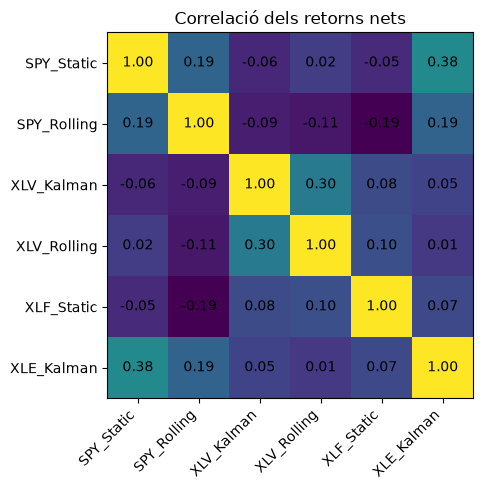

In [76]:
# HEATMAP DE CORRELACIONS

fig, ax = plt.subplots(
    figsize=(6, 5)
)

imatge = ax.imshow(
    correlacio_retorns
)

ax.set_xticks(
    range(
        len(correlacio_retorns.columns)
    )
)

ax.set_yticks(
    range(
        len(correlacio_retorns.index)
    )
)

ax.set_xticklabels(
    correlacio_retorns.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    correlacio_retorns.index
)


for i in range(
    len(correlacio_retorns.index)
):

    for j in range(
        len(correlacio_retorns.columns)
    ):

        ax.text(
            j,
            i,
            f"{correlacio_retorns.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )


ax.set_title(
    "Correlació dels retorns nets"
)

plt.tight_layout()
plt.show()

In [77]:
# SOLAPAMENT JACCARD

noms_candidats = list(
    candidats_cartera.keys()
)


solapament_jaccard = pd.DataFrame(
    index=noms_candidats,
    columns=noms_candidats,
    dtype=float
)


for estrategia_i in noms_candidats:

    activa_i = (
        actius_candidats[
            estrategia_i
        ].astype(bool)
    )


    for estrategia_j in noms_candidats:

        activa_j = (
            actius_candidats[
                estrategia_j
            ].astype(bool)
        )


        dies_ambdues = (
            activa_i
            & activa_j
        ).sum()


        dies_alguna = (
            activa_i
            | activa_j
        ).sum()


        if dies_alguna > 0:

            jaccard = (
                dies_ambdues
                / dies_alguna
            )

        else:

            jaccard = np.nan


        solapament_jaccard.loc[
            estrategia_i,
            estrategia_j
        ] = jaccard


solapament_jaccard.round(3)

,SPY_Static,SPY_Rolling,XLV_Kalman,XLV_Rolling,XLF_Static,XLE_Kalman
SPY_Static,1.000,0.170,0.070,0.071,0.076,0.074
SPY_Rolling,0.170,1.000,0.073,0.067,0.050,0.050
XLV_Kalman,0.070,0.073,1.000,0.219,0.236,0.094
XLV_Rolling,0.071,0.067,0.219,1.000,0.269,0.122
XLF_Static,0.076,0.050,0.236,0.269,1.000,0.074
XLE_Kalman,0.074,0.050,0.094,0.122,0.074,1.000


In [78]:
# CONSENS ENTRE MODELS DE LA MATEIXA PARELLA

parelles_models_consens = [
    (
        "SPY_Static",
        "SPY_Rolling"
    ),
    (
        "XLV_Kalman",
        "XLV_Rolling"
    )
]


resultats_consens = []


for model_1, model_2 in (
    parelles_models_consens
):

    pos_1 = (
        posicions_candidats[
            model_1
        ]
    )

    pos_2 = (
        posicions_candidats[
            model_2
        ]
    )


    tots_dos_actius = (
        (pos_1 != 0)
        &
        (pos_2 != 0)
    )


    n_coincidencies = (
        tots_dos_actius.sum()
    )


    if n_coincidencies > 0:

        mateixa_direccio = (
            pos_1[
                tots_dos_actius
            ]
            ==
            pos_2[
                tots_dos_actius
            ]
        ).mean()


        direccio_contraria = (
            pos_1[
                tots_dos_actius
            ]
            ==
            -pos_2[
                tots_dos_actius
            ]
        ).mean()

    else:

        mateixa_direccio = np.nan
        direccio_contraria = np.nan


    almenys_un_actiu = (
        (pos_1 != 0)
        |
        (pos_2 != 0)
    )


    pct_dies_ambdos = (
        tots_dos_actius.sum()
        / almenys_un_actiu.sum()
    )


    resultats_consens.append(
        {
            "Model_1":
                model_1,

            "Model_2":
                model_2,

            "Dies_Ambdos_Actius":
                n_coincidencies,

            "Pct_Solapament":
                pct_dies_ambdos,

            "Pct_Mateixa_Direccio":
                mateixa_direccio,

            "Pct_Direccio_Contraria":
                direccio_contraria
        }
    )


consens_models = pd.DataFrame(
    resultats_consens
)

consens_models

,Model_1,Model_2,Dies_Ambdos_Actius,Pct_Solapament,Pct_Mateixa_Direccio,Pct_Direccio_Contraria
0,SPY_Static,SPY_Rolling,24,0.170213,1.000000,0.000000
1,XLV_Kalman,XLV_Rolling,110,0.218688,0.809091,0.190909


### 12.1. Fusió dels models en motors de parella

Els diferents models aplicats sobre una mateixa parella no es tractaran com estratègies independents.

Construirem un únic motor per parella combinant els pesos proposats pels models candidats.

Per una parella amb dos models:

$$
w_{A,t}^{motor}
=
\frac{
w_{A,t}^{(1)}
+
w_{A,t}^{(2)}
}{2},
$$

i equivalentment:

$$
w_{B,t}^{motor}
=
\frac{
w_{B,t}^{(1)}
+
w_{B,t}^{(2)}
}{2}.
$$

Aquesta regla produeix automàticament:

- exposició elevada quan els models coincideixen,
- exposició reduïda quan només un model detecta oportunitat,
- reducció o cancel·lació de l'exposició quan els models discrepen.

Els costos es calcularan després d'agregar els pesos, evitant comptar com dues operacions independents posicions que econòmicament pertanyen a la mateixa parella.

In [79]:
# DEFINICIO DELS MOTORS DE PARELLA

definicio_motors = {

    "SPY_Motor": {
        "Parella": "SPY_IVV",
        "Components": [
            "SPY_Static",
            "SPY_Rolling"
        ]
    },

    "XLV_Motor": {
        "Parella": "XLV_VHT",
        "Components": [
            "XLV_Kalman",
            "XLV_Rolling"
        ]
    },

    "XLF_Motor": {
        "Parella": "XLF_VFH",
        "Components": [
            "XLF_Static"
        ]
    },

    "XLE_Motor": {
        "Parella": "XLE_VDE",
        "Components": [
            "XLE_Kalman"
        ]
    }
}

In [81]:
# CONSTRUCCIO DELS MOTORS DE PARELLA

def construir_motor_parella(
    nom_parella,
    components,
    cost_bps=2.0
):

    ticker_A, ticker_B = (
        parelles_candidates[
            nom_parella
        ]
    )


    pesos_A = pd.concat(
        [
            detalls_candidats[
                component
            ]["Pes_A"]
            for component in components
        ],
        axis=1
    ).mean(axis=1)


    pesos_B = pd.concat(
        [
            detalls_candidats[
                component
            ]["Pes_B"]
            for component in components
        ],
        axis=1
    ).mean(axis=1)


    retorn_A = (
        validation[ticker_A]
        .pct_change()
        .fillna(0)
    )


    retorn_B = (
        validation[ticker_B]
        .pct_change()
        .fillna(0)
    )


    retorn_brut = (
        pesos_A * retorn_A
        +
        pesos_B * retorn_B
    )


    turnover = (
        pesos_A.diff().abs().fillna(
            abs(pesos_A.iloc[0])
        )
        +
        pesos_B.diff().abs().fillna(
            abs(pesos_B.iloc[0])
        )
    )


    cost_decimal = (
        cost_bps
        / 10_000
    )


    cost = (
        cost_decimal
        * turnover
    )


    retorn_net = (
        retorn_brut
        - cost
    )


    exposicio_gross = (
        pesos_A.abs()
        +
        pesos_B.abs()
    )


    detall = pd.DataFrame(
        {
            "Pes_A": pesos_A,
            "Pes_B": pesos_B,
            "Exposicio_Gross": exposicio_gross,
            "Retorn_Brut": retorn_brut,
            "Turnover": turnover,
            "Cost": cost,
            "Retorn_Net": retorn_net
        }
    )


    detall["Actiu"] = (
        detall["Exposicio_Gross"]
        > 1e-12
    )


    return detall

In [82]:
# EXECUCIO DELS MOTORS

detalls_motors = {}

retorns_motors = pd.DataFrame(
    index=validation.index
)

exposicions_motors = pd.DataFrame(
    index=validation.index
)


for nom_motor, config in (
    definicio_motors.items()
):

    detall = (
        construir_motor_parella(
            nom_parella=config["Parella"],
            components=config["Components"],
            cost_bps=2.0
        )
    )


    detalls_motors[
        nom_motor
    ] = detall


    retorns_motors[
        nom_motor
    ] = (
        detall["Retorn_Net"]
    )


    exposicions_motors[
        nom_motor
    ] = (
        detall["Exposicio_Gross"]
    )

In [83]:
# RESUM DELS MOTORS

resum_motors = []


for nom_motor in (
    retorns_motors.columns
):

    retorn = (
        retorns_motors[
            nom_motor
        ]
    )


    exposicio = (
        exposicions_motors[
            nom_motor
        ]
    )


    capital = (
        (1 + retorn)
        .cumprod()
    )


    rend_anual = (
        capital.iloc[-1]
        ** (
            252
            / len(capital)
        )
        - 1
    )


    vol_anual = (
        retorn.std()
        * np.sqrt(252)
    )


    if retorn.std() > 0:

        sharpe = (
            retorn.mean()
            / retorn.std()
            * np.sqrt(252)
        )

    else:

        sharpe = np.nan


    drawdown = (
        capital
        / capital.cummax()
        - 1
    )


    resum_motors.append(
        {
            "Motor":
                nom_motor,

            "Rend_Anual":
                rend_anual,

            "Vol_Anual":
                vol_anual,

            "Sharpe":
                sharpe,

            "Max_DD":
                drawdown.min(),

            "Exposicio_Mitjana":
                exposicio.mean(),

            "Exposicio_Max":
                exposicio.max(),

            "Pct_Dies_Actiu":
                (
                    exposicio > 0
                ).mean(),

            "Turnover_Total":
                detalls_motors[
                    nom_motor
                ]["Turnover"].sum()
        }
    )


resum_motors = pd.DataFrame(
    resum_motors
)

resum_motors

,Motor,Rend_Anual,Vol_Anual,Sharpe,Max_DD,Exposicio_Mitjana,Exposicio_Max,Pct_Dies_Actiu,Turnover_Total
0,SPY_Motor,0.001900,0.002164,0.878142,-0.001853,0.081845,1.0,0.139881,51.0
1,XLV_Motor,0.005004,0.009700,0.519494,-0.012735,0.284045,1.0,0.499008,50.0
2,XLF_Motor,0.000985,0.009508,0.108283,-0.012110,0.432540,1.0,0.432540,41.0
3,XLE_Motor,0.004514,0.007092,0.638647,-0.010493,0.100198,1.0,0.100198,50.0


In [84]:
# ASSIGNACIO DE CAPITAL

capital_exemple = 100_000


n_motors = len(
    resum_motors
)


pesos_equal = pd.Series(
    1 / n_motors,
    index=resum_motors["Motor"]
)


volatilitats = (
    resum_motors
    .set_index("Motor")[
        "Vol_Anual"
    ]
)


pesos_inverse_vol = (
    1
    / volatilitats
)


pesos_inverse_vol = (
    pesos_inverse_vol
    / pesos_inverse_vol.sum()
)


assignacio_capital = pd.DataFrame(
    {
        "Equal_Capital":
            pesos_equal,

        "Inverse_Vol":
            pesos_inverse_vol
    }
)


assignacio_capital[
    "EUR_Equal"
] = (
    capital_exemple
    * assignacio_capital[
        "Equal_Capital"
    ]
)


assignacio_capital[
    "EUR_InverseVol"
] = (
    capital_exemple
    * assignacio_capital[
        "Inverse_Vol"
    ]
)


assignacio_capital.round(4)

,Equal_Capital,Inverse_Vol,EUR_Equal,EUR_InverseVol
Motor,,,,
SPY_Motor,0.25,0.5696,25000.0,56955.6647
XLV_Motor,0.25,0.1271,25000.0,12705.3426
XLF_Motor,0.25,0.1296,25000.0,12961.1762
XLE_Motor,0.25,0.1738,25000.0,17377.8165


In [85]:
# CARTERA EQUAL CAPITAL VS INVERSE VOL

def resum_cartera(
    nom,
    pesos
):

    retorn_cartera = (
        retorns_motors
        .mul(
            pesos,
            axis=1
        )
        .sum(axis=1)
    )


    exposicio_cartera = (
        exposicions_motors
        .mul(
            pesos,
            axis=1
        )
        .sum(axis=1)
    )


    capital = (
        (1 + retorn_cartera)
        .cumprod()
    )


    rend_anual = (
        capital.iloc[-1]
        ** (
            252
            / len(capital)
        )
        - 1
    )


    vol_anual = (
        retorn_cartera.std()
        * np.sqrt(252)
    )


    if retorn_cartera.std() > 0:

        sharpe = (
            retorn_cartera.mean()
            / retorn_cartera.std()
            * np.sqrt(252)
        )

    else:

        sharpe = np.nan


    drawdown = (
        capital
        / capital.cummax()
        - 1
    )


    return {
        "Cartera":
            nom,

        "Rend_Anual":
            rend_anual,

        "Vol_Anual":
            vol_anual,

        "Sharpe":
            sharpe,

        "Max_DD":
            drawdown.min(),

        "Exposicio_Gross_Mitjana":
            exposicio_cartera.mean(),

        "Exposicio_Gross_Max":
            exposicio_cartera.max()
    }


comparacio_carteres = pd.DataFrame(
    [
        resum_cartera(
            "Equal Capital",
            pesos_equal
        ),

        resum_cartera(
            "Inverse Vol",
            pesos_inverse_vol
        )
    ]
)


comparacio_carteres

,Cartera,Rend_Anual,Vol_Anual,Sharpe,Max_DD,Exposicio_Gross_Mitjana,Exposicio_Gross_Max
0,Equal Capital,0.003121,0.004156,0.751827,-0.005114,0.224657,1.0
1,Inverse Vol,0.002643,0.002685,0.984229,-0.003210,0.156179,1.0


## 13. Continuació prevista i tancament de la recerca

Si l'estratègia hagués mantingut un edge econòmic suficient després de costos i fora de mostra, el desenvolupament hauria continuat amb una capa completa de cartera.

### Motors de parella

Els diferents models aplicats sobre una mateixa parella s'haurien combinat en un únic motor econòmic:

$$
\text{models}
\rightarrow
\text{senyal agregat de la parella}
\rightarrow
\text{posició final}.
$$

Quan dos models coincidissin en direcció, el motor hauria pogut utilitzar més exposició. Quan només un model detectés una oportunitat, l'exposició s'hauria reduït. Quan els models es contradiguessin, la posició s'hauria anul·lat o reduït fortament.

### Distribució del capital

Després s'haurien comparat diverses regles simples d'assignació:

- equal capital;
- inverse volatility;
- equal risk contribution;
- pressupostos de risc amb un límit màxim per parella;
- redistribució del capital entre els motors actius.

Per cada motor $i$, els pesos finals haurien tingut la forma:

$$
w_{A,i,t}
=
\lambda_{i,t}
\frac{p_{i,t}}{1+|\beta_{i,t}|},
$$

$$
w_{B,i,t}
=
-\lambda_{i,t}
\frac{p_{i,t}\beta_{i,t}}{1+|\beta_{i,t}|},
$$

on $\lambda_{i,t}$ representa el pressupost de capital o risc assignat al motor.

### Backtest de cartera

El backtest s'hauria calculat a nivell dels ETFs finals, agregant totes les posicions abans de calcular:

- exposició gross i neta;
- turnover real de la cartera;
- costos de transacció;
- correlació entre motors;
- drawdown de cartera;
- concentració per parella i sector;
- volatilitat i Sharpe de cartera.

També s'haurien incorporat hipòtesis més realistes sobre:

- remuneració del cash;
- costos de finançament;
- costos de venda en curt;
- bid-ask spread i slippage;
- límits de marge i liquiditat.

### Test final i walk-forward

Un cop congelades les parelles, els models, els thresholds, els costos i la regla d'assignació, el període de test s'hauria obert una única vegada.

Després s'hauria construït un procés walk-forward:

$$
\text{train}
\rightarrow
\text{validation}
\rightarrow
\text{operació futura}
\rightarrow
\text{recalibració}.
$$

Finalment, el sistema hauria passat a paper trading abans de considerar capital real.

### Conclusió real del projecte

Els experiments amb dades reals han mostrat que diverses parelles presenten reversió estadística i un petit edge brut.

Tanmateix, l'edge net després de costos és massa reduït per justificar la complexitat del sistema en la seva forma actual. Les configuracions que sobreviuen train i validation produeixen rendibilitats anuals petites i sensibles a les hipòtesis de fricció.

Continuar ajustant thresholds, finestres o models sobre les mateixes dades augmentaria el risc d'overfitting.

Per tant, aquest notebook es tanca com un resultat de recerca vàlid:

$$
\boxed{
\text{reversió estadística}
\neq
\text{estratègia econòmicament explotable}
}
$$

El període de test es manté sense utilitzar i no es continuarà optimitzant aquesta estratègia sobre el mateix conjunt de dades.